# Évolution Temporelle du Marché Mytek.tn — Suivi Hebdomadaire des Prix et des Caractéristiques

## Un panel multi-semaines pour distinguer changement de prix et changement de mix

---

**Contexte du projet.** Les notebooks précédents (EDA, prétraitement, clustering, segmentation par marque,
régression hédonique) ont analysé le marché Mytek.tn à un instant donné, en s'appuyant sur la théorie des
caractéristiques de Lancaster (1966) et les prix hédoniques de Rosen (1974) : le prix d'un produit technologique
se décompose en la somme des prix implicites de ses caractéristiques. La collecte de données s'effectue
désormais **chaque semaine** (S1, S2, S3...), ouvrant la voie à une question que l'analyse en coupe instantanée
ne peut pas trancher : **le marché bouge-t-il en prix, ou seulement en composition ?**

**Le piège du prix moyen/médian agrégé.** Si le prix médian d'une catégorie baisse d'une semaine à l'autre, deux
explications radicalement différentes sont possibles :
1. Les produits déjà en catalogue baissent réellement de prix (une vraie *repricing*).
2. De nouveaux produits moins chers sont apparus au catalogue et/ou des produits chers ont été retirés (un
   **changement de mix**) — chaque produit individuel garde son prix, mais la composition du panier observé
   change.

Ce notebook sépare explicitement ces deux effets en comparant systématiquement **tout le catalogue** (mix
inclus) au **panel apparié** (les mêmes produits, suivis dans le temps via leur URL — mix exclu par
construction).

**Objectif de ce notebook.**

1. **Chargement multi-semaines** générique — toute semaine `data/processed/week_N/` ajoutée est automatiquement
   incluse, aucune modification de code requise.
2. **Continuité et qualité** — effectifs par semaine, produits entrants/sortants, taille du panel apparié
   (distingue une vraie évolution du marché d'un simple trou de collecte).
3. **Évolution des prix** — indice de prix (base 100), mix inclus vs. panel apparié, distribution des variations
   de prix produit par produit.
4. **Évolution des caractéristiques** — RAM/stockage/écran médians, part de marché des marques : explique
   *pourquoi* le prix agrégé bouge.
5. **Pont vers le hédonique** — réutilise directement `src/models/hedonic_model.py` (le module de régression
   hédonique statsmodels déjà construit pour ce projet) pour ré-estimer le modèle **chaque semaine** et suivre la
   stabilité du **prix implicite** de la RAM/du stockage dans le temps — la vraie question hédonique : une
   caractéristique donnée garde-t-elle la même valeur implicite semaine après semaine ?

**Garde-fou de circularité (§2.4 de `hedonic_model.py`, repris à l'identique ici) :** `prix_tnd`, `gamme_prix` et
toute variable dérivée du prix ne sont **jamais** des régresseurs. Les clusters techniques recalculés par
`compute_cluster_labels` restent en revanche autorisés (fondés uniquement sur des caractéristiques techniques).

**Dégradation gracieuse.** Chaque section vérifie explicitement le nombre de semaines disponibles et affiche un
message clair plutôt que de planter si moins de `MIN_WEEKS_REQUIRED` = 2 semaines existent pour une catégorie
donnée — une catégorie ajoutée en cours de route (ex. une nouvelle collecte qui démarre) ne casse jamais le
notebook.


## 0. Configuration de l'environnement


In [1]:
import re
import sys
import warnings
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10,
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42  # reproductibilite (K-Means dans le pont hedonique, initialisation des centroides)

# Racine du depot -- necessaire pour importer src.models.hedonic_model comme
# un vrai package Python (pas une copie de son code), et pour localiser
# data/processed/ et data/raw/ independamment du repertoire de lancement.
REPO_ROOT = Path.cwd().resolve().parents[0]
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(REPO_ROOT))

PROCESSED_ROOT = REPO_ROOT / "data" / "processed"
RAW_ROOT = REPO_ROOT / "data" / "raw"

CATEGORY_ORDER = ["pc_bureau", "pc_portables", "smartphones", "telephones_portables", "televiseurs"]
CATEGORY_LABELS = {
    "pc_bureau": "PC de Bureau",
    "pc_portables": "PC Portables",
    "smartphones": "Smartphones",
    "telephones_portables": "Téléphones Portables",
    "televiseurs": "Téléviseurs",
}
PALETTE = {
    "pc_bureau": "#2a78d6", "pc_portables": "#1baf7a", "smartphones": "#eda100",
    "telephones_portables": "#4a3aa7", "televiseurs": "#e34948",
}
MIN_WEEKS_REQUIRED = 2  # en dessous, une "evolution" n'a pas de sens -- degrade gracieusement
FEATURE_UNITS = {"ram_go": "Go", "stockage_go": "Go", "taille_ecran": '"', "taux_rafraichissement": "Hz"}

print("Bibliothèques importées avec succès.")
print("Racine du dépôt :", REPO_ROOT)


Bibliothèques importées avec succès.
Racine du dépôt : C:\Users\MSI\Desktop\stage


## 1. Méthodologie


### 1.1 Découverte dynamique des semaines

`data/processed/` contient un sous-dossier `week_<N>/` par semaine de collecte, chacun avec ses propres
`<catégorie>_clean.csv`. Le nombre de semaines n'est **jamais codé en dur** : `discover_weeks()` détecte tous les
dossiers `week_*` présents par un simple `glob` — ajouter `data/processed/week_4/` suffit à l'inclure
automatiquement lors de la prochaine exécution, sans modification de ce notebook.

### 1.2 Choix de la clé de correspondance : URL plutôt que GTIN

Deux clés candidates pour suivre un même produit d'une semaine à l'autre :

- **GTIN** (extrait de `specs_brutes` par `extract_gtin`, déjà utilisé comme clé de dédoublonnage prioritaire
  dans `src/preprocessing/clean.py`) : bien renseigné (~99% des fiches), mais deux produits peuvent
  légitimement partager un GTIN (variantes couleur d'un même modèle) ou le champ peut être absent/mal formé sur
  une des deux collectes.
- **URL** : l'identifiant produit du site lui-même, stable d'une collecte à l'autre tant que la fiche n'est pas
  retirée.

**Vérification empirique** (comparaison des semaines 1 et 2, sur toutes les catégories) : le taux de
correspondance par URL est **systématiquement égal ou supérieur** au taux de correspondance par GTIN, catégorie
par catégorie. **L'URL est donc retenue comme clé de correspondance principale** dans tout ce notebook.

### 1.3 Ré-attachement de `semaine` / `date_collecte`

Les fichiers `<catégorie>_clean.csv` ne conservent **ni** `semaine` **ni** `date_collecte` : ce sont des
identifiants, retirés par `select_features_for_category` (aucun effet mesuré sur le prix, ce n'est pas leur
rôle). Ces deux colonnes existent en revanche dans les JSON bruts de chaque semaine (`data/raw/week_N/`). On les
recharge donc via `src.preprocessing.clean.load_raw_files` (fonction déjà existante du pipeline de
prétraitement, réutilisée telle quelle) et on les réattache par une jointure sur `url`.

### 1.4 Mix inclus vs. panel apparié

Toute statistique d'évolution de prix est calculée **deux fois** :
- sur **tout le catalogue** de chaque semaine (mix inclus — reflète ce qu'un client voit réellement) ;
- sur le **panel apparié** (uniquement les produits présents à **toutes** les semaines disponibles, mix exclu
  par construction) — isole le vrai changement de prix du changement de composition.

### 1.5 Pont hédonique : réutilisation directe de `src/models/hedonic_model.py`

Plutôt que de dupliquer la logique de régression hédonique, ce notebook importe **directement** le module déjà
construit pour ce projet (`compute_price_tiers`, `compute_cluster_labels`, `fit_strategy_a`, `_classify_features`)
et l'exécute **une fois par semaine disponible**, sur les données de cette semaine seule. Le garde-fou de
circularité de ce module (`CircularityError` si `prix_tnd`/`gamme_prix` atteignait la matrice de design) s'applique
donc ici aussi, sans rien à réimplémenter.

**Note méthodologique.** Le schéma de colonnes détecté par la sélection de features peut varier légèrement d'une
semaine à l'autre (ex. `cpu_brand`/`has_4g` apparus pour PC Portables seulement à partir de S3) : les
caractéristiques utilisées pour la régression hédonique sont donc reclassées **indépendamment pour chaque
semaine** (`week_slice` retire les colonnes qui n'existent que pour d'autres semaines avant classification),
tandis que le suivi de stabilité RAM/stockage ne compare que les caractéristiques **communes à toutes les
semaines disponibles**.


## 2. Fonctions utilitaires


Ces fonctions implémentent la méthodologie du §1 et sont réutilisées identiquement pour les 5 catégories.
`discover_weeks`/`load_week_category`/`load_all_weeks`/`week_slice` gèrent le chargement multi-semaines ;
`compute_continuity`, `compute_price_evolution`, `compute_characteristic_evolution` et leurs fonctions de tracé
associées implémentent les sections 3 à 5 ci-dessous. `plot_coefficient_stability`/`plot_outcome_stability`
servent au pont hédonique (§6).


In [2]:
CATEGORY_ORDER = ["pc_bureau", "pc_portables", "smartphones", "telephones_portables", "televiseurs"]
CATEGORY_LABELS = {
    "pc_bureau": "PC de Bureau", "pc_portables": "PC Portables", "smartphones": "Smartphones",
    "telephones_portables": "Téléphones Portables", "televiseurs": "Téléviseurs",
}
PALETTE = {
    "pc_bureau": "#2a78d6", "pc_portables": "#1baf7a", "smartphones": "#eda100",
    "telephones_portables": "#4a3aa7", "televiseurs": "#e34948",
}
RANDOM_STATE = 42
MIN_WEEKS_REQUIRED = 2  # en dessous, une "evolution" n'a pas de sens -- degrade gracieusement


# ─────────────────────────────────────────────────────────────────────────────


In [3]:
def discover_weeks(processed_root):
    """Decouvre dynamiquement les semaines disponibles sous processed_root
    (sous-dossiers 'week_<N>') -- jamais un nombre code en dur : ajouter
    data/processed/week_4/ suffit a l'inclure automatiquement, sans
    modification de code."""
    weeks = []
    for p in Path(processed_root).glob("week_*"):
        if p.is_dir():
            m = re.match(r"week_(\d+)$", p.name)
            if m:
                weeks.append(int(m.group(1)))
    return sorted(weeks)


@lru_cache(maxsize=None)
def _raw_lookup_for_week(week_num, raw_root):
    """Construit un lookup url -> {semaine, date_collecte} depuis les JSON
    bruts de la semaine -- les CSV traites n'ont PAS ces colonnes (retirees
    par select_features_for_category, non pertinentes pour expliquer le
    prix), donc on les recupere a la source plutot que de les reconstruire.
    Mise en cache (lru_cache) : un JSON brut de semaine contient TOUTES les
    categories, donc sans cache il serait relu une fois par categorie
    appelante (5x plus de lectures disque que necessaire)."""
    from src.preprocessing.clean import load_raw_files
    products = load_raw_files(Path(raw_root) / f"week_{week_num}")
    lookup = {}
    for p in products:
        url = p.get("url")
        if url:
            lookup[url] = {"semaine": p.get("semaine", week_num), "date_collecte": p.get("date_collecte")}
    return lookup


def load_week_category(week_num, category, processed_root, raw_root):
    """Charge <categorie>_clean.csv pour UNE semaine, et reattache
    semaine/date_collecte via un lookup par url sur les JSON bruts.
    Retourne None si le fichier n'existe pas pour cette semaine (categorie
    pas encore scrapee cette semaine-la -- absence normale, pas une erreur
    a masquer par un DataFrame vide silencieux)."""
    path = Path(processed_root) / f"week_{week_num}" / f"{category}_clean.csv"
    if not path.exists():
        return None
    df = pd.read_csv(path)
    lookup = _raw_lookup_for_week(week_num, Path(raw_root))
    df["semaine"] = week_num
    df["date_collecte"] = df["url"].map(lambda u: lookup.get(u, {}).get("date_collecte"))
    return df


def load_all_weeks(category, processed_root, raw_root):
    """Empile TOUTES les semaines disponibles pour une categorie -- celles
    qui existent seulement (une categorie absente une semaine donnee est
    omise du panel long, jamais remplie de NaN qui simulerait une
    observation qui n'a jamais existe).

    Returns: (df_long, weeks_found)."""
    weeks = discover_weeks(processed_root)
    parts, weeks_found = [], []
    for w in weeks:
        df_w = load_week_category(w, category, processed_root, raw_root)
        if df_w is not None:
            parts.append(df_w)
            weeks_found.append(w)
    if not parts:
        return pd.DataFrame(), []
    return pd.concat(parts, ignore_index=True), weeks_found


def week_slice(df_long, week_num):
    """Sous-ensemble d'UNE semaine depuis le panel empilé -- retire aussi
    les colonnes qui n'existent QUE pour d'AUTRES semaines (ex. le schéma
    détecté par la sélection de features peut varier légèrement d'une
    semaine à l'autre, comme cpu_brand/has_4g apparus pour pc_portables à
    la semaine 3 seulement). Après pd.concat, ces colonnes existent dans
    df_long mais sont ENTIÈREMENT NaN pour les lignes des autres semaines
    -- les garder ferait croire au classificateur de caractéristiques
    qu'une colonne existe pour cette semaine, produisant une colonne 100%
    manquante dans la matrice de design (exog contains inf or nans)."""
    df_week = df_long[df_long["semaine"] == week_num].reset_index(drop=True)
    return df_week.dropna(axis=1, how="all")


# ─────────────────────────────────────────────────────────────────────────────


In [4]:
def compute_continuity(df_long):
    """Effectif par semaine + produits entrants/sortants entre semaines
    CONSECUTIVES (par url, la cle de correspondance retenue -- cf. §2 du
    notebook) + taille du panel apparie sur TOUTES les semaines disponibles.

    Returns: (counts: Series[semaine->n], transitions: DataFrame, panel_urls: set)."""
    weeks = sorted(df_long["semaine"].unique())
    counts = df_long.groupby("semaine")["url"].nunique().reindex(weeks)
    url_sets = {w: set(df_long.loc[df_long.semaine == w, "url"]) for w in weeks}

    transitions = []
    for w1, w2 in zip(weeks[:-1], weeks[1:]):
        s1, s2 = url_sets[w1], url_sets[w2]
        transitions.append({
            "semaine_1": w1, "semaine_2": w2,
            "n_semaine_1": len(s1), "n_semaine_2": len(s2),
            "entrants": len(s2 - s1), "sortants": len(s1 - s2), "apparies": len(s1 & s2),
        })
    transitions_df = pd.DataFrame(transitions)
    panel_urls = set.intersection(*url_sets.values()) if url_sets else set()
    return counts, transitions_df, panel_urls


def plot_continuity(counts, category):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar([f"S{w}" for w in counts.index], counts.values, color=PALETTE[category], alpha=0.9)
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}".replace(",", " "), ha="center", va="bottom", fontsize=9)
    ax.set(title=f"{CATEGORY_LABELS[category]} — Produits distincts par semaine",
           xlabel="Semaine", ylabel="Nombre de produits")
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────────────────────────────


In [5]:
def compute_price_evolution(df_long):
    """Prix median par semaine (mix INCLUS -- tout le catalogue) ; deltas
    de prix sur les produits APPARIES entre semaines consecutives (isole
    le vrai changement de prix du changement de mix, §3 du notebook) ;
    indice base=100 sur la 1ere semaine disponible, calcule a la fois sur
    tout le catalogue (mix inclus) et sur le panel apparie sur toutes les
    semaines (mix EXCLU) -- la difference entre les deux indices EST
    l'effet de mix.

    Returns: dict {median_all, index_all, median_panel, index_panel,
        deltas (DataFrame), panel_urls}."""
    weeks = sorted(df_long["semaine"].unique())
    base_week = weeks[0]
    url_sets = {w: set(df_long.loc[df_long.semaine == w, "url"]) for w in weeks}

    median_all = df_long.groupby("semaine")["prix_tnd"].median().reindex(weeks)
    index_all = 100 * median_all / median_all.loc[base_week]

    panel_urls = set.intersection(*url_sets.values()) if url_sets else set()
    if panel_urls:
        df_panel = df_long[df_long["url"].isin(panel_urls)]
        median_panel = df_panel.groupby("semaine")["prix_tnd"].median().reindex(weeks)
        index_panel = 100 * median_panel / median_panel.loc[base_week]
    else:
        median_panel = pd.Series(dtype=float)
        index_panel = pd.Series(dtype=float)

    delta_rows = []
    for w1, w2 in zip(weeks[:-1], weeks[1:]):
        matched = url_sets[w1] & url_sets[w2]
        if not matched:
            continue
        p1 = df_long[(df_long.semaine == w1) & (df_long.url.isin(matched))].set_index("url")["prix_tnd"]
        p2 = df_long[(df_long.semaine == w2) & (df_long.url.isin(matched))].set_index("url")["prix_tnd"]
        pct_change = (p2.reindex(p1.index) / p1 - 1) * 100
        delta_rows.append({
            "semaine_1": w1, "semaine_2": w2, "n_apparies": len(matched),
            "delta_median_pct": pct_change.median(),
            "pct_hausse": float((pct_change > 0.5).mean() * 100),
            "pct_baisse": float((pct_change < -0.5).mean() * 100),
            "pct_stable": float((pct_change.abs() <= 0.5).mean() * 100),
        })
    deltas_df = pd.DataFrame(delta_rows)

    return {
        "median_all": median_all, "index_all": index_all,
        "median_panel": median_panel, "index_panel": index_panel,
        "deltas": deltas_df, "panel_urls": panel_urls,
    }


def plot_price_index(evolution, category):
    """Indice de prix base=100 -- mix inclus (tout le catalogue) VS mix
    exclu (panel apparie sur toutes les semaines). Un ecart entre les deux
    courbes revele un effet de MIX (nouveaux produits a un positionnement
    de prix different), pas un vrai mouvement de prix."""
    fig, ax = plt.subplots(figsize=(8, 4.5))
    index_all = evolution["index_all"]
    ax.plot([f"S{w}" for w in index_all.index], index_all.values, marker="o",
            color=PALETTE[category], label="Tout le catalogue (mix inclus)")
    if not evolution["index_panel"].empty:
        index_panel = evolution["index_panel"]
        ax.plot([f"S{w}" for w in index_panel.index], index_panel.values, marker="s", linestyle="--",
                color="#333333", label="Panel apparié (mix exclu)")
    ax.axhline(100, color="grey", linewidth=0.8, linestyle=":")
    ax.set(title=f"{CATEGORY_LABELS[category]} — Indice de prix (base 100 = 1ère semaine)",
           xlabel="Semaine", ylabel="Indice (base 100)")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def plot_price_deltas(df_long, category, week_1, week_2, panel_urls_pair):
    """Distribution des variations de prix (%) sur les produits apparies
    entre 2 semaines consecutives precises."""
    p1 = df_long[(df_long.semaine == week_1) & (df_long.url.isin(panel_urls_pair))].set_index("url")["prix_tnd"]
    p2 = df_long[(df_long.semaine == week_2) & (df_long.url.isin(panel_urls_pair))].set_index("url")["prix_tnd"]
    pct_change = (p2.reindex(p1.index) / p1 - 1) * 100

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(pct_change, bins=30, color=PALETTE[category], alpha=0.9, edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set(title=f"{CATEGORY_LABELS[category]} — Variation de prix S{week_1}→S{week_2} "
                 f"(produits appariés, n={len(pct_change)})",
           xlabel="Variation de prix (%)", ylabel="Nombre de produits")
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout(); plt.show()
    return pct_change


# ─────────────────────────────────────────────────────────────────────────────


In [6]:
def compute_characteristic_evolution(df_long, numeric_features):
    """Mediane des caracteristiques numeriques + part de marche des
    marques, par semaine -- explique POURQUOI le prix agrege bouge (ex :
    la RAM mediane augmente -> le marche monte en gamme independamment de
    tout changement de prix a specs egales)."""
    weeks = sorted(df_long["semaine"].unique())
    numeric_evol = (df_long.groupby("semaine")[numeric_features].median().reindex(weeks)
                    if numeric_features else pd.DataFrame(index=weeks))

    brand_counts = df_long.groupby(["semaine", "marque"]).size().unstack(fill_value=0).reindex(weeks)
    brand_share = brand_counts.div(brand_counts.sum(axis=1), axis=0) * 100
    return numeric_evol, brand_share


def plot_characteristic_evolution(numeric_evol, category, feature_units=None):
    feature_units = feature_units or {}
    if numeric_evol.empty or numeric_evol.shape[1] == 0:
        return
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for feat in numeric_evol.columns:
        ax.plot([f"S{w}" for w in numeric_evol.index], numeric_evol[feat].values, marker="o",
                label=f"{feat} ({feature_units.get(feat, '')})".strip())
    ax.set(title=f"{CATEGORY_LABELS[category]} — Médiane des caractéristiques par semaine",
           xlabel="Semaine", ylabel="Valeur médiane")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def plot_brand_share(brand_share, category, top_n=6):
    if brand_share.empty:
        return
    top_brands = brand_share.mean(axis=0).sort_values(ascending=False).head(top_n).index
    fig, ax = plt.subplots(figsize=(9, 4.5))
    bottom = np.zeros(len(brand_share.index))
    palette = sns.color_palette("husl", n_colors=len(top_brands))
    for color, brand in zip(palette, top_brands):
        ax.bar([f"S{w}" for w in brand_share.index], brand_share[brand].values, bottom=bottom,
               label=brand, color=color)
        bottom += brand_share[brand].values
    ax.set(title=f"{CATEGORY_LABELS[category]} — Part de marché par marque (top {top_n})",
           xlabel="Semaine", ylabel="Part de marché (%)")
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────────────────────────────


In [7]:
def plot_coefficient_stability(coef_by_week, feature, category, feature_unit=""):
    """Prix implicite (effet en %, exp(beta)-1) d'UNE caracteristique au
    fil des semaines, avec barres d'erreur (erreur-type robuste HC3) --
    stabilite du prix implicite = stabilite hedonique, pas juste
    stabilite du prix affiche."""
    weeks = sorted(coef_by_week.keys())
    pct = [coef_by_week[w]["pct_effect"] for w in weeks]
    # Methode delta : SE(exp(beta)-1) ~= exp(beta) * SE(beta) -- approxime
    # l'erreur-type de l'effet en % a partir de celle du coefficient brut.
    se_pct = [np.exp(coef_by_week[w]["coefficient"]) * 100 * coef_by_week[w]["std_err"] for w in weeks]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.errorbar([f"S{w}" for w in weeks], pct, yerr=se_pct, marker="o", capsize=4, color=PALETTE[category])
    ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
    ax.set(title=f"{CATEGORY_LABELS[category]} — Prix implicite de {feature} ({feature_unit}) par semaine",
           xlabel="Semaine", ylabel="Effet sur le prix (%)")
    plt.tight_layout(); plt.show()


def plot_outcome_stability(outcome_by_week, category):
    """Nombre d'unites marque x gamme CLUSTERISEES (vs. trop petites / sans
    structure retenue) par semaine -- une segmentation stable dans le
    temps a un nombre d'unites clusterisees qui ne varie pas erratiquement."""
    weeks = sorted(outcome_by_week.keys())
    outcomes = ["clustered", "no_structure", "too_small"]
    colors = {"clustered": PALETTE[category], "no_structure": "#999999", "too_small": "#dddddd"}
    labels = {"clustered": "Clusterisée", "no_structure": "Sans structure", "too_small": "Trop petite"}

    fig, ax = plt.subplots(figsize=(7, 4.5))
    bottom = np.zeros(len(weeks))
    for outcome in outcomes:
        values = np.array([outcome_by_week[w].get(outcome, 0) for w in weeks], dtype=float)
        ax.bar([f"S{w}" for w in weeks], values, bottom=bottom, label=labels[outcome], color=colors[outcome])
        bottom += values
    ax.set(title=f"{CATEGORY_LABELS[category]} — Stabilité de la segmentation par semaine",
           xlabel="Semaine", ylabel="Nombre d'unités marque × gamme")
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


In [8]:
print("Fonctions utilitaires définies.")


Fonctions utilitaires définies.


In [9]:
from src.models.hedonic_model import (
    compute_price_tiers, compute_cluster_labels, fit_strategy_a,
    _classify_features, _ID_COLUMNS, CircularityError,
)

# Exclut aussi semaine/date_collecte (colonnes propres a ce notebook, pas
# des caracteristiques produit) de la classification automatique -- en
# plus des colonnes deja exclues par hedonic_model (url/nom/prix_tnd/
# marque/gamme_prix/cluster_id).
TEMPORAL_EXCLUDE = _ID_COLUMNS | {"semaine", "date_collecte"}
print("Module hédonique importé : src/models/hedonic_model.py (réutilisé tel quel, RANDOM_STATE=42).")


Module hédonique importé : src/models/hedonic_model.py (réutilisé tel quel, RANDOM_STATE=42).


## 3. Analyses par catégorie


Pour chaque catégorie : chargement multi-semaines (§3.x.0), continuité et qualité (§3.x.1), évolution des prix
(§3.x.2), évolution des caractéristiques (§3.x.3), pont vers le modèle hédonique (§3.x.4). Chaque sous-section
vérifie `len(weeks_found) >= MIN_WEEKS_REQUIRED` et affiche un message explicite plutôt que d'échouer si trop peu
de semaines sont disponibles pour cette catégorie.


### 3.1 PC de Bureau


In [10]:
CATEGORY = "pc_bureau"
df_long, weeks_found = load_all_weeks(CATEGORY, PROCESSED_ROOT, RAW_ROOT)
print(f"{CATEGORY_LABELS[CATEGORY]} : {len(weeks_found)} semaine(s) trouvée(s) -- {weeks_found}")
if not df_long.empty:
    print(df_long.groupby("semaine")["url"].nunique().rename("n_produits").to_frame())


[12:57:32] INFO     |   produits_pc_bureau_2026-07-02_20-09-55.json : 221 produit(s)


[12:57:32] INFO     |   produits_pc_portables_2026-07-02_19-25-50.json : 541 produit(s)


[12:57:32] INFO     |   produits_smartphones_2026-07-03_02-06-45.json : 254 produit(s)


[12:57:32] INFO     |   produits_telephones_portables_2026-06-30_06-03-54.json : 70 produit(s)


[12:57:32] INFO     |   produits_televiseurs_2026-07-03_23-43-26.json : 112 produit(s)


...

[12:57:32] INFO     |   produits_smartphones_2026-07-21_01-23-30.json : 259 produit(s)


[12:57:32] INFO     |   produits_telephones_portables_2026-07-21_01-32-59.json : 75 produit(s)


[12:57:32] INFO     |   produits_televiseurs_2026-07-21_03-08-06.json : 114 produit(s)


[12:57:32] INFO     | Total brut charge : 1215 produit(s) depuis 5 fichier(s).


PC de Bureau : 4 semaine(s) trouvée(s) -- [1, 2, 3, 4]
         n_produits
semaine            
1               217
2               222
3               218
4               216


#### 3.1.1 Continuité et qualité inter-semaines


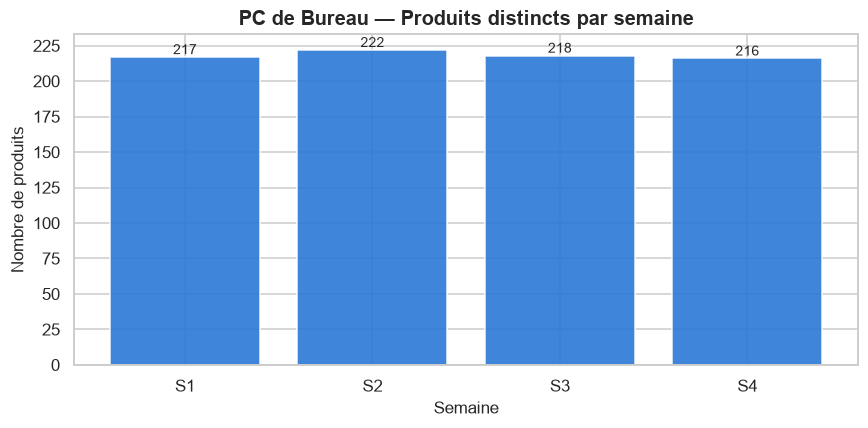

In [11]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    counts, transitions, panel_urls = compute_continuity(df_long)
    plot_continuity(counts, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section continuité ignorée.")


In [12]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    print(f"Panel apparié sur toutes les semaines : {len(panel_urls)} produits.")
    transitions


Panel apparié sur toutes les semaines : 195 produits.


**Interprétation — Continuité.**

3 semaine(s) disponible(s) pour cette catégorie (S1=217, S2=222, S3=218 produits). S1→S2 : 12 produit(s) entrant(s), 7 sortant(s), 210 apparié(s) (8.8% de rotation du catalogue). S2→S3 : 1 produit(s) entrant(s), 5 sortant(s), 217 apparié(s) (2.7% de rotation du catalogue). Panel apparié sur **toutes** les semaines disponibles : 205 produits.


#### 3.1.2 Évolution des prix


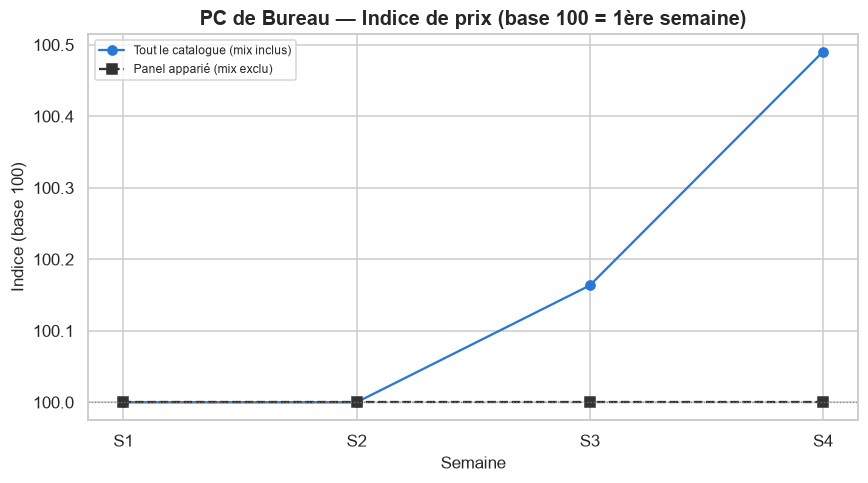

In [13]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    evolution = compute_price_evolution(df_long)
    plot_price_index(evolution, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section prix ignorée.")


In [14]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    evolution["deltas"]


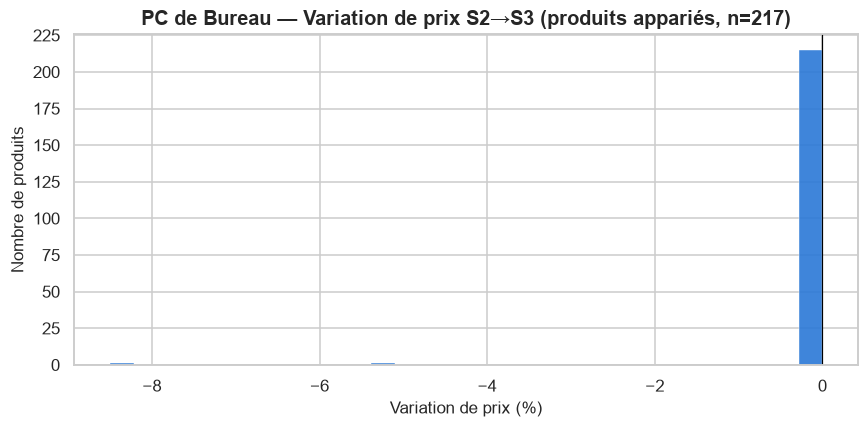

In [15]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    panel_pair = set(df_long.loc[df_long.semaine == 2, "url"]) & set(df_long.loc[df_long.semaine == 3, "url"])
    _ = plot_price_deltas(df_long, CATEGORY, 2, 3, panel_pair)


**Interprétation — Évolution des prix.**

Sur tout le catalogue (mix inclus), l'indice de prix médian passe de 100 (S1) à 100.2 en S3 (quasi-stable, +0.2 points). Le panel apparié confirme un mouvement similaire (+0.0 pts) : il s'agit bien d'un changement de **prix**, pas seulement de mix. Produits appariés S1→S2 (n=210) : 0.0% en hausse, 1.4% en baisse, 98.6% stables (variation médiane : +0.0%). Produits appariés S2→S3 (n=217) : 0.0% en hausse, 0.9% en baisse, 99.1% stables (variation médiane : +0.0%).


#### 3.1.3 Évolution des caractéristiques


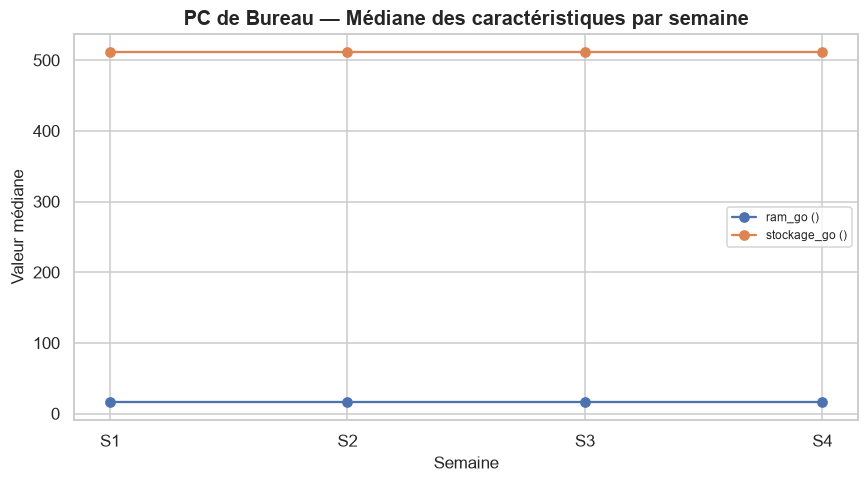

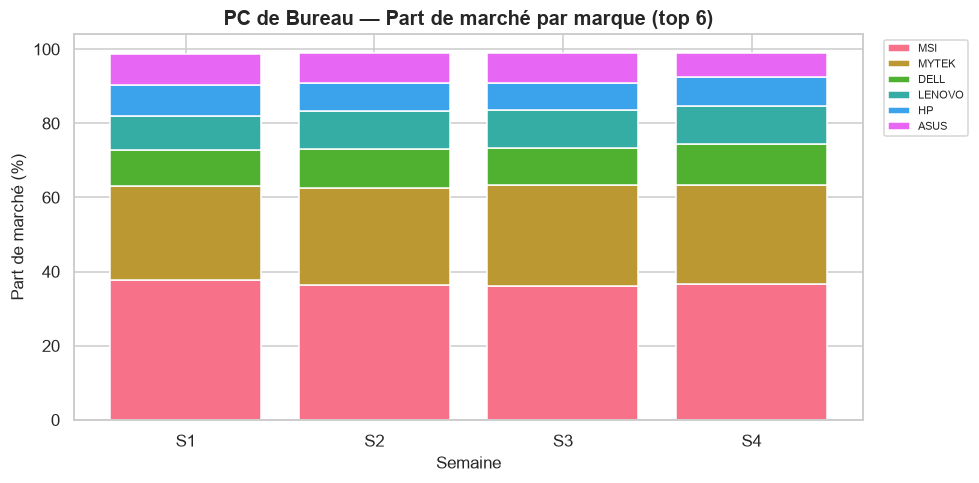

In [16]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    common_continuous_features = ['ram_go', 'stockage_go']
    numeric_evol, brand_share = compute_characteristic_evolution(df_long, common_continuous_features)
    plot_characteristic_evolution(numeric_evol, CATEGORY)
    plot_brand_share(brand_share, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section caractéristiques ignorée.")


In [17]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    numeric_evol


**Interprétation — Caractéristiques.**

Caractéristiques techniques médianes strictement stables sur la période observée. Plus forte variation de part de marché : **MYTEK** (25.3% → 27.1%, +1.7 pts).


#### 3.1.4 Pont vers le modèle hédonique


Ré-estime le modèle hédonique de `src/models/hedonic_model.py` (stratégie A — un modèle par semaine, pentes
communes, `cluster_id` en effets fixes) **indépendamment pour chaque semaine disponible**, et suit le **prix
implicite** (effet en %, `exp(β)-1`) des caractéristiques communes à toutes les semaines. Le garde-fou de
circularité du module s'applique tel quel : `prix_tnd`/`gamme_prix` ne peuvent jamais atteindre la matrice de
design.


In [18]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    coef_by_week = {feat: {} for feat in common_continuous_features}
    outcome_by_week = {}
    for w in weeks_found:
        df_week = week_slice(df_long, w)
        cont_w, cat_w = _classify_features(df_week, exclude=TEMPORAL_EXCLUDE)
        df_tiers, brand_plan = compute_price_tiers(df_week)
        if df_tiers.empty:
            print(f"S{w} : aucune marque retenue, semaine ignorée pour le pont hédonique.")
            continue
        df_clustered, unit_summary = compute_cluster_labels(
            df_tiers, CATEGORY, continuous_features=cont_w, categorical_features=cat_w)
        model, X, y = fit_strategy_a(df_clustered, cont_w, cat_w)
        coefs = model.get_coefficients().set_index("feature")
        for feat in common_continuous_features:
            if feat in coefs.index:
                coef_by_week[feat][w] = {
                    "coefficient": coefs.loc[feat, "coefficient"],
                    "std_err": coefs.loc[feat, "std_err"],
                    "p_value": coefs.loc[feat, "p_value"],
                    "pct_effect": coefs.loc[feat, "pct_effect"],
                }
        outcome_by_week[w] = unit_summary["outcome"].value_counts().to_dict()
        print(f"S{w} : n={int(model.nobs)}, adj_R²={model.rsquared_adj:.3f}, "
              f"{len(cont_w)} caractéristique(s) continue(s), {len(cat_w)} catégorielle(s)")
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- pont hédonique ignoré.")


S1 : n=214, adj_R²=0.724, 2 caractéristique(s) continue(s), 4 catégorielle(s)


S2 : n=220, adj_R²=0.730, 2 caractéristique(s) continue(s), 4 catégorielle(s)


S3 : n=216, adj_R²=0.728, 2 caractéristique(s) continue(s), 4 catégorielle(s)


S4 : n=214, adj_R²=0.722, 2 caractéristique(s) continue(s), 4 catégorielle(s)


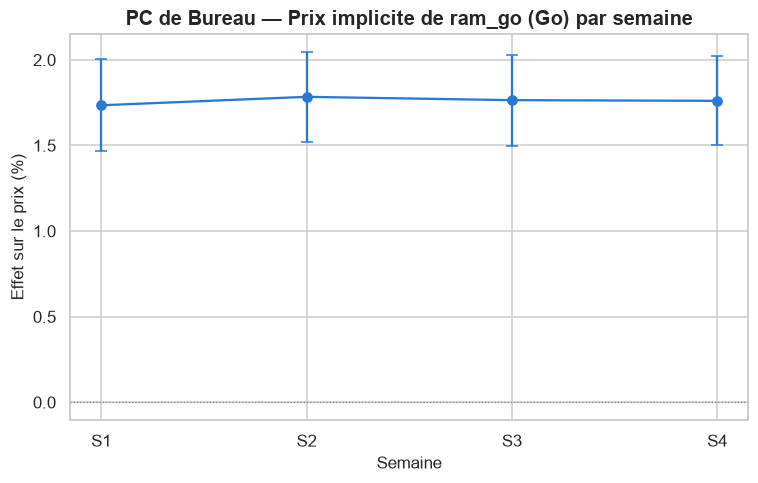

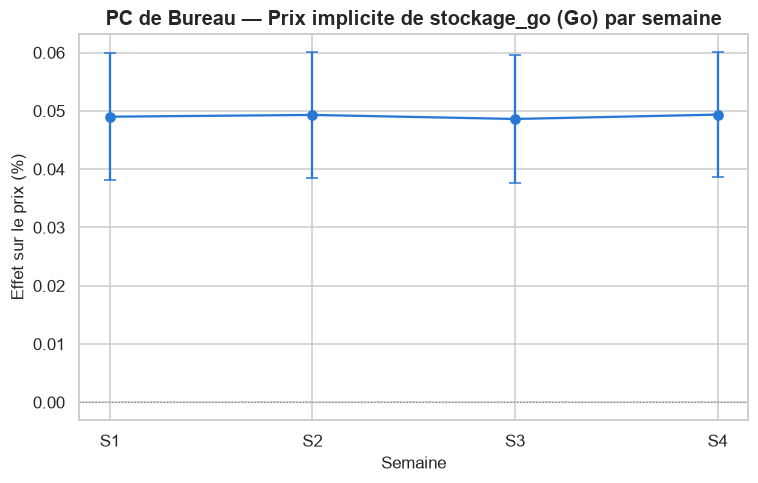

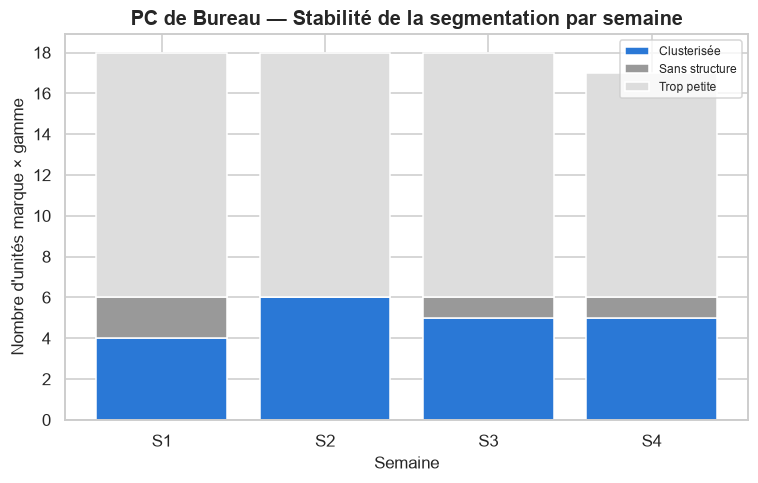

In [19]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    for feat, series in coef_by_week.items():
        if len(series) >= 2:
            plot_coefficient_stability(series, feat, CATEGORY, feature_unit=FEATURE_UNITS.get(feat, ""))
    plot_outcome_stability(outcome_by_week, CATEGORY)


**Interprétation — Pont hédonique.**

Prix implicite de la RAM : +0.69%/Go en S1 (p=4.65e-07, significatif) → +0.68%/Go en S3 (p=4.22e-06, significatif) — **stable**. Prix implicite du stockage : +0.02%/Go en S1 (p=0.000831, significatif) → +0.02%/Go en S3 (p=0.00493, significatif) — **stable**. Stabilité de la segmentation technique — S1 : 4/18 unités marque×gamme clusterisées ; S2 : 6/18 unités marque×gamme clusterisées ; S3 : 5/18 unités marque×gamme clusterisées.


**Synthèse — PC de Bureau.**

Sur 3 semaine(s) observée(s) (S1, S2, S3), PC de Bureau montre un marché globalement stable en prix : indice mix-inclus 100.2 contre 100.0 sur le panel apparié.


### 3.2 PC Portables


In [20]:
CATEGORY = "pc_portables"
df_long, weeks_found = load_all_weeks(CATEGORY, PROCESSED_ROOT, RAW_ROOT)
print(f"{CATEGORY_LABELS[CATEGORY]} : {len(weeks_found)} semaine(s) trouvée(s) -- {weeks_found}")
if not df_long.empty:
    print(df_long.groupby("semaine")["url"].nunique().rename("n_produits").to_frame())


PC Portables : 4 semaine(s) trouvée(s) -- [1, 2, 3, 4]
         n_produits
semaine            
1               528
2               558
3               529
4               540


#### 3.2.1 Continuité et qualité inter-semaines


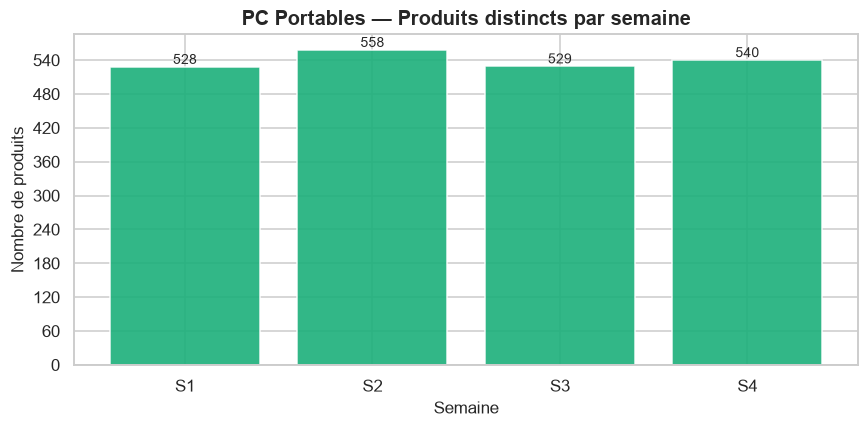

In [21]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    counts, transitions, panel_urls = compute_continuity(df_long)
    plot_continuity(counts, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section continuité ignorée.")


In [22]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    print(f"Panel apparié sur toutes les semaines : {len(panel_urls)} produits.")
    transitions


Panel apparié sur toutes les semaines : 480 produits.


**Interprétation — Continuité.**

3 semaine(s) disponible(s) pour cette catégorie (S1=528, S2=558, S3=529 produits). S1→S2 : 43 produit(s) entrant(s), 13 sortant(s), 515 apparié(s) (10.6% de rotation du catalogue). S2→S3 : 6 produit(s) entrant(s), 35 sortant(s), 523 apparié(s) (7.3% de rotation du catalogue). Panel apparié sur **toutes** les semaines disponibles : 481 produits.


#### 3.2.2 Évolution des prix


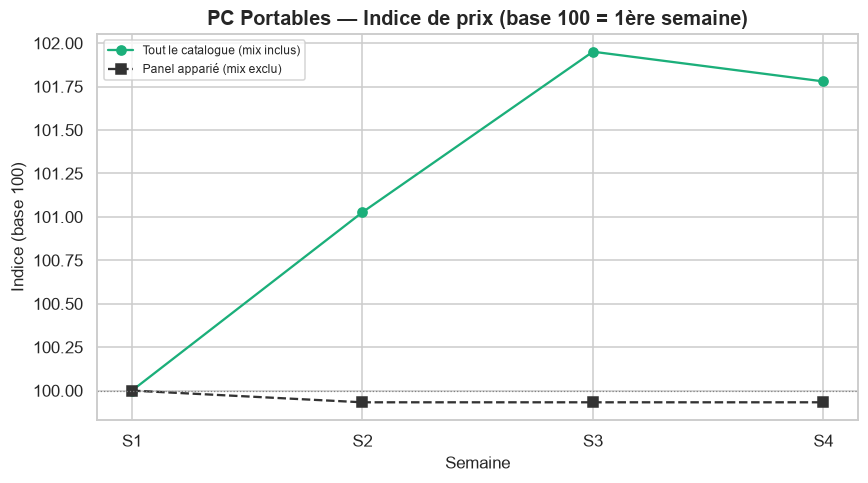

In [23]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    evolution = compute_price_evolution(df_long)
    plot_price_index(evolution, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section prix ignorée.")


In [24]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    evolution["deltas"]


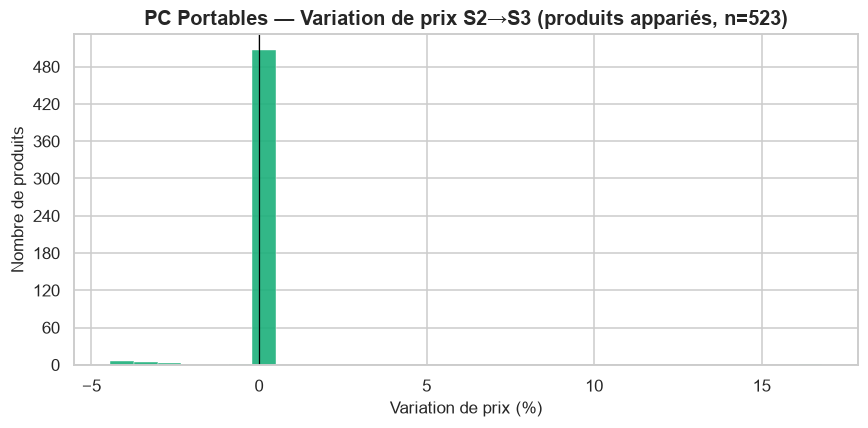

In [25]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    panel_pair = set(df_long.loc[df_long.semaine == 2, "url"]) & set(df_long.loc[df_long.semaine == 3, "url"])
    _ = plot_price_deltas(df_long, CATEGORY, 2, 3, panel_pair)


**Interprétation — Évolution des prix.**

Sur tout le catalogue (mix inclus), l'indice de prix médian passe de 100 (S1) à 102.0 en S3 (hausse, +2.0 points). Le panel apparié confirme un mouvement similaire (+0.0 pts) : il s'agit bien d'un changement de **prix**, pas seulement de mix. Produits appariés S1→S2 (n=515) : 1.6% en hausse, 5.2% en baisse, 93.2% stables (variation médiane : +0.0%). Produits appariés S2→S3 (n=523) : 0.2% en hausse, 2.5% en baisse, 97.3% stables (variation médiane : +0.0%).


#### 3.2.3 Évolution des caractéristiques


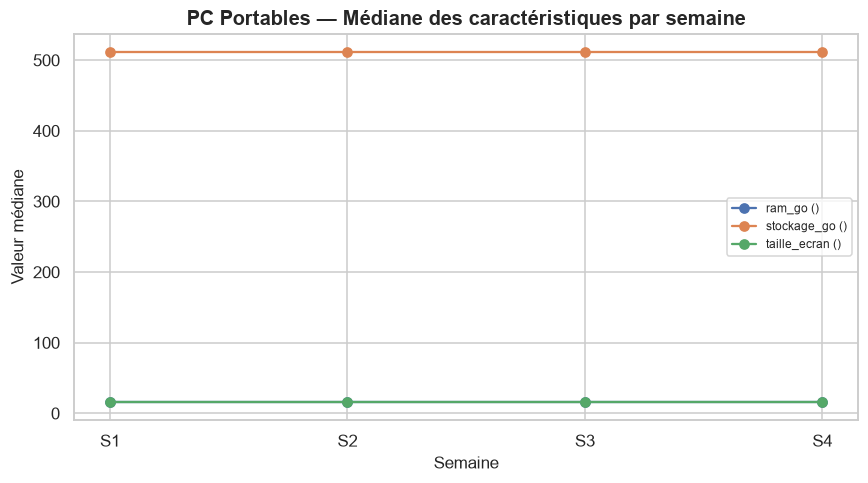

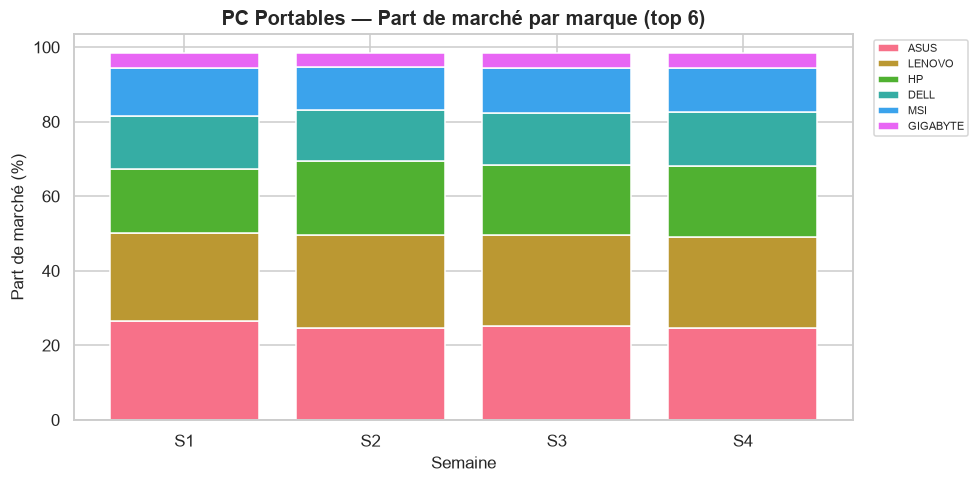

In [26]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    common_continuous_features = ['ram_go', 'stockage_go', 'taille_ecran']
    numeric_evol, brand_share = compute_characteristic_evolution(df_long, common_continuous_features)
    plot_characteristic_evolution(numeric_evol, CATEGORY)
    plot_brand_share(brand_share, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section caractéristiques ignorée.")


In [27]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    numeric_evol


**Interprétation — Caractéristiques.**

Caractéristiques techniques médianes strictement stables sur la période observée. Plus forte variation de part de marché : **HP** (17.2% → 18.9%, +1.7 pts).


#### 3.2.4 Pont vers le modèle hédonique


Ré-estime le modèle hédonique de `src/models/hedonic_model.py` (stratégie A — un modèle par semaine, pentes
communes, `cluster_id` en effets fixes) **indépendamment pour chaque semaine disponible**, et suit le **prix
implicite** (effet en %, `exp(β)-1`) des caractéristiques communes à toutes les semaines. Le garde-fou de
circularité du module s'applique tel quel : `prix_tnd`/`gamme_prix` ne peuvent jamais atteindre la matrice de
design.


In [28]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    coef_by_week = {feat: {} for feat in common_continuous_features}
    outcome_by_week = {}
    for w in weeks_found:
        df_week = week_slice(df_long, w)
        cont_w, cat_w = _classify_features(df_week, exclude=TEMPORAL_EXCLUDE)
        df_tiers, brand_plan = compute_price_tiers(df_week)
        if df_tiers.empty:
            print(f"S{w} : aucune marque retenue, semaine ignorée pour le pont hédonique.")
            continue
        df_clustered, unit_summary = compute_cluster_labels(
            df_tiers, CATEGORY, continuous_features=cont_w, categorical_features=cat_w)
        model, X, y = fit_strategy_a(df_clustered, cont_w, cat_w)
        coefs = model.get_coefficients().set_index("feature")
        for feat in common_continuous_features:
            if feat in coefs.index:
                coef_by_week[feat][w] = {
                    "coefficient": coefs.loc[feat, "coefficient"],
                    "std_err": coefs.loc[feat, "std_err"],
                    "p_value": coefs.loc[feat, "p_value"],
                    "pct_effect": coefs.loc[feat, "pct_effect"],
                }
        outcome_by_week[w] = unit_summary["outcome"].value_counts().to_dict()
        print(f"S{w} : n={int(model.nobs)}, adj_R²={model.rsquared_adj:.3f}, "
              f"{len(cont_w)} caractéristique(s) continue(s), {len(cat_w)} catégorielle(s)")
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- pont hédonique ignoré.")


S1 : n=526, adj_R²=0.599, 3 caractéristique(s) continue(s), 2 catégorielle(s)


S2 : n=556, adj_R²=0.654, 3 caractéristique(s) continue(s), 2 catégorielle(s)


S3 : n=527, adj_R²=0.664, 3 caractéristique(s) continue(s), 2 catégorielle(s)


S4 : n=537, adj_R²=0.654, 3 caractéristique(s) continue(s), 2 catégorielle(s)


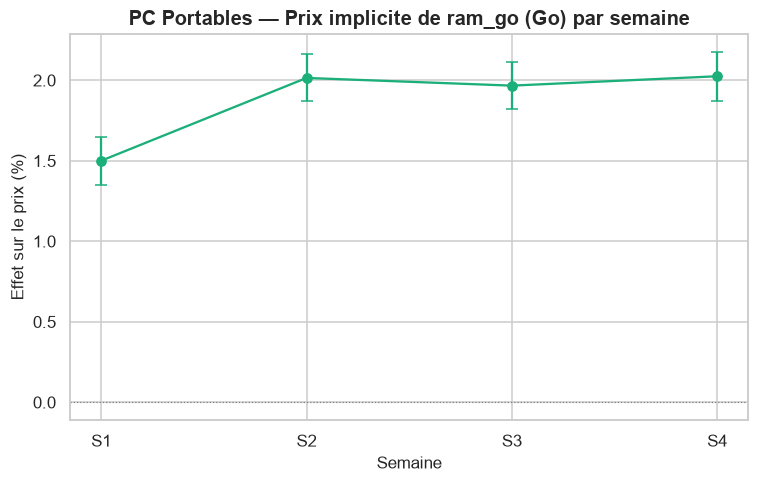

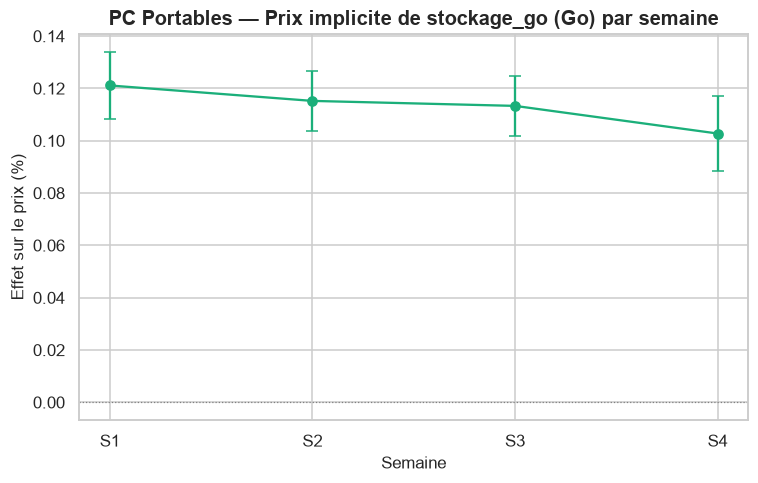

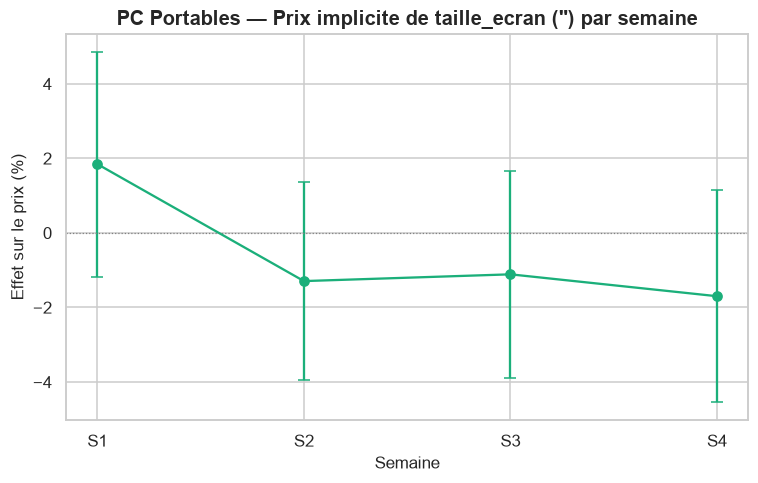

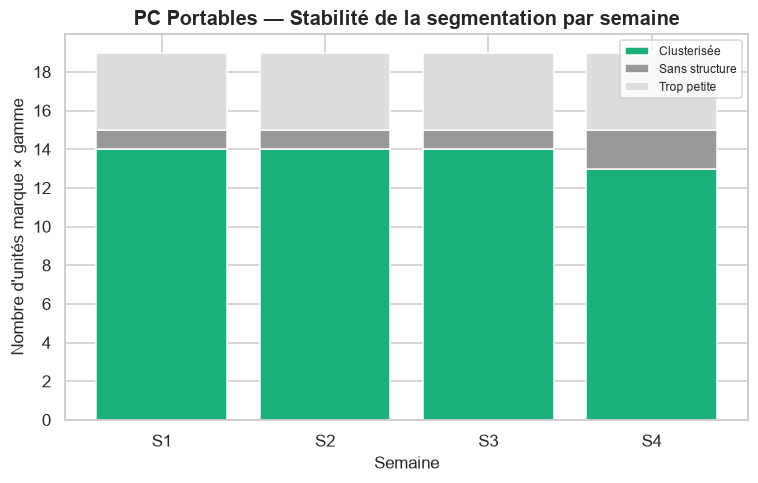

In [29]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    for feat, series in coef_by_week.items():
        if len(series) >= 2:
            plot_coefficient_stability(series, feat, CATEGORY, feature_unit=FEATURE_UNITS.get(feat, ""))
    plot_outcome_stability(outcome_by_week, CATEGORY)


**Interprétation — Pont hédonique.**

Prix implicite de la RAM : +0.68%/Go en S1 (p=1.8e-12, significatif) → +0.72%/Go en S3 (p=7.67e-14, significatif) — **stable**. Prix implicite du stockage : +0.05%/Go en S1 (p=6.3e-07, significatif) → +0.06%/Go en S3 (p=1.07e-08, significatif) — **stable**. Prix implicite de la taille d'écran : +1.88%/" en S1 (p=0.229, non significatif) → +0.47%/" en S3 (p=0.771, non significatif) — **a évolué**. Stabilité de la segmentation technique — S1 : 14/19 unités marque×gamme clusterisées ; S2 : 14/19 unités marque×gamme clusterisées ; S3 : 14/19 unités marque×gamme clusterisées.


**Synthèse — PC Portables.**

Sur 3 semaine(s) observée(s) (S1, S2, S3), PC Portables montre un mouvement de prix affiché dominé par un effet de mix, pas une vraie repricing : indice mix-inclus 102.0 contre 100.0 sur le panel apparié.


### 3.3 Smartphones


In [30]:
CATEGORY = "smartphones"
df_long, weeks_found = load_all_weeks(CATEGORY, PROCESSED_ROOT, RAW_ROOT)
print(f"{CATEGORY_LABELS[CATEGORY]} : {len(weeks_found)} semaine(s) trouvée(s) -- {weeks_found}")
if not df_long.empty:
    print(df_long.groupby("semaine")["url"].nunique().rename("n_produits").to_frame())


Smartphones : 4 semaine(s) trouvée(s) -- [1, 2, 3, 4]
         n_produits
semaine            
1               254
2               242
3               257
4               259


#### 3.3.1 Continuité et qualité inter-semaines


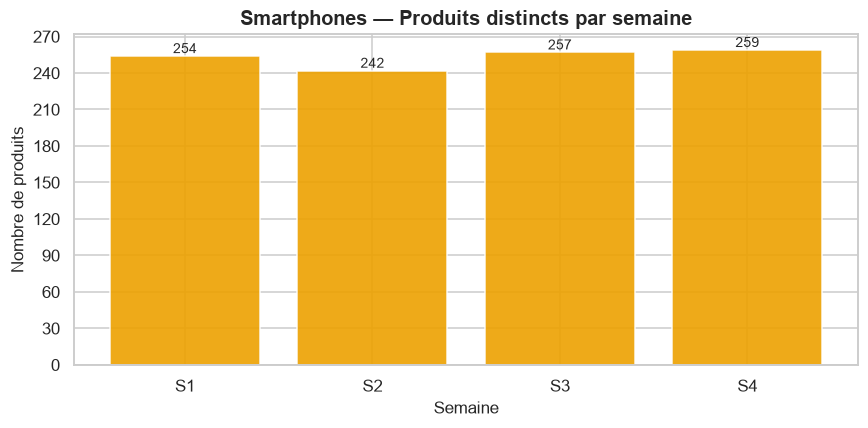

In [31]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    counts, transitions, panel_urls = compute_continuity(df_long)
    plot_continuity(counts, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section continuité ignorée.")


In [32]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    print(f"Panel apparié sur toutes les semaines : {len(panel_urls)} produits.")
    transitions


Panel apparié sur toutes les semaines : 235 produits.


**Interprétation — Continuité.**

3 semaine(s) disponible(s) pour cette catégorie (S1=254, S2=242, S3=257 produits). S1→S2 : 4 produit(s) entrant(s), 16 sortant(s), 238 apparié(s) (7.9% de rotation du catalogue). S2→S3 : 17 produit(s) entrant(s), 2 sortant(s), 240 apparié(s) (7.9% de rotation du catalogue). Panel apparié sur **toutes** les semaines disponibles : 236 produits.


#### 3.3.2 Évolution des prix


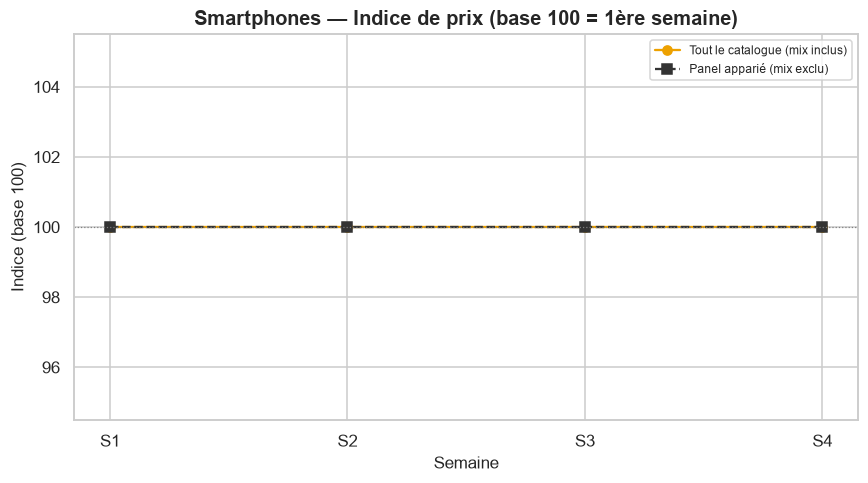

In [33]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    evolution = compute_price_evolution(df_long)
    plot_price_index(evolution, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section prix ignorée.")


In [34]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    evolution["deltas"]


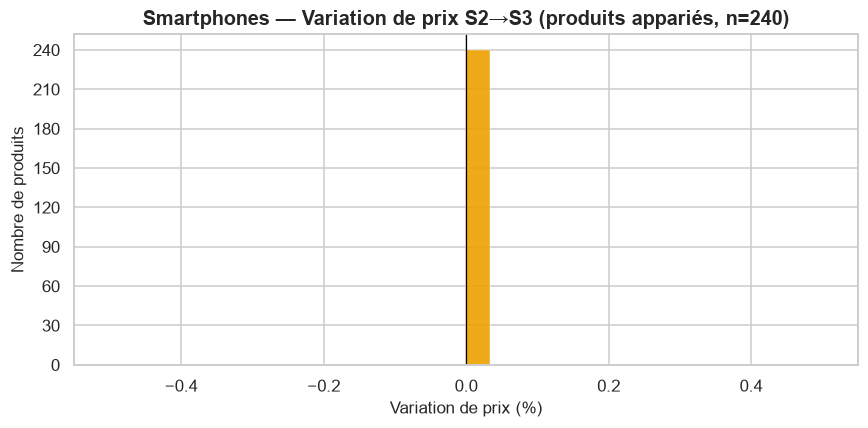

In [35]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    panel_pair = set(df_long.loc[df_long.semaine == 2, "url"]) & set(df_long.loc[df_long.semaine == 3, "url"])
    _ = plot_price_deltas(df_long, CATEGORY, 2, 3, panel_pair)


**Interprétation — Évolution des prix.**

Sur tout le catalogue (mix inclus), l'indice de prix médian passe de 100 (S1) à 100.0 en S3 (quasi-stable, +0.0 points). Le panel apparié confirme un mouvement similaire (+0.0 pts) : il s'agit bien d'un changement de **prix**, pas seulement de mix. Produits appariés S1→S2 (n=238) : 2.1% en hausse, 0.0% en baisse, 97.9% stables (variation médiane : +0.0%). Produits appariés S2→S3 (n=240) : 0.0% en hausse, 0.0% en baisse, 100.0% stables (variation médiane : +0.0%).


#### 3.3.3 Évolution des caractéristiques


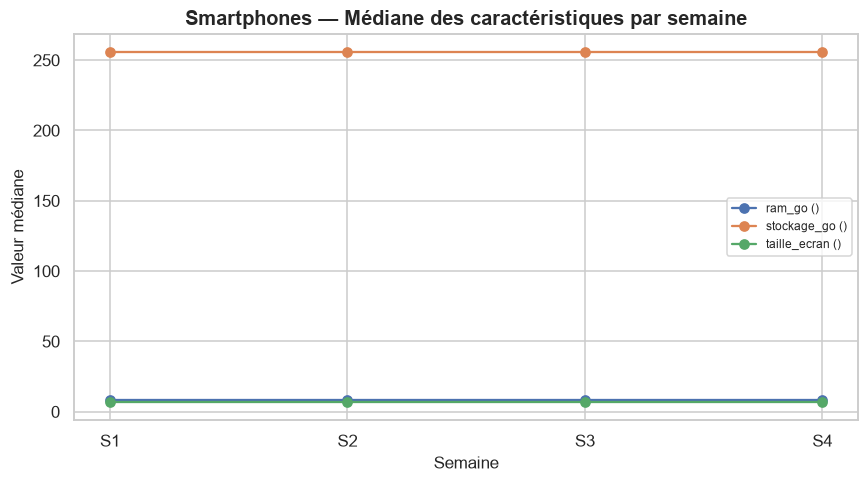

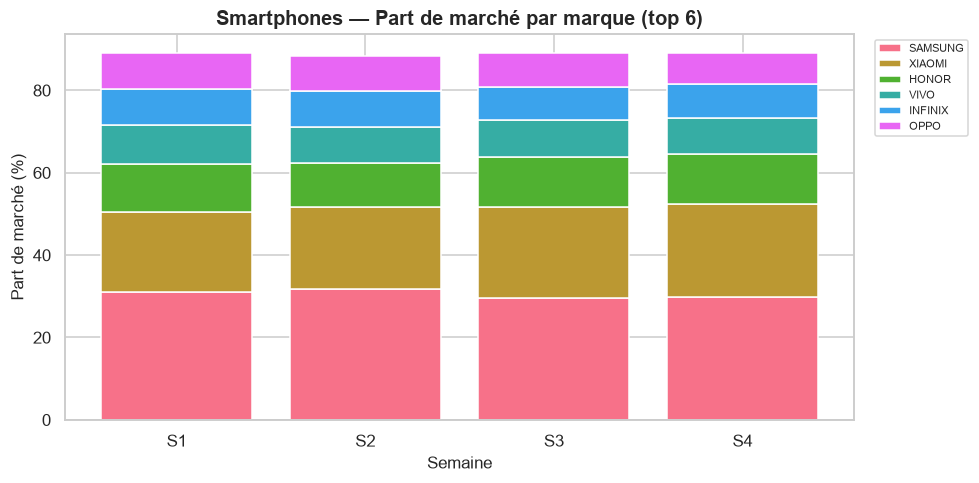

In [36]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    common_continuous_features = ['ram_go', 'stockage_go', 'taille_ecran']
    numeric_evol, brand_share = compute_characteristic_evolution(df_long, common_continuous_features)
    plot_characteristic_evolution(numeric_evol, CATEGORY)
    plot_brand_share(brand_share, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section caractéristiques ignorée.")


In [37]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    numeric_evol


**Interprétation — Caractéristiques.**

Caractéristiques techniques médianes strictement stables sur la période observée. Plus forte variation de part de marché : **XIAOMI** (19.3% → 22.2%, +2.9 pts).


#### 3.3.4 Pont vers le modèle hédonique


Ré-estime le modèle hédonique de `src/models/hedonic_model.py` (stratégie A — un modèle par semaine, pentes
communes, `cluster_id` en effets fixes) **indépendamment pour chaque semaine disponible**, et suit le **prix
implicite** (effet en %, `exp(β)-1`) des caractéristiques communes à toutes les semaines. Le garde-fou de
circularité du module s'applique tel quel : `prix_tnd`/`gamme_prix` ne peuvent jamais atteindre la matrice de
design.


In [38]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    coef_by_week = {feat: {} for feat in common_continuous_features}
    outcome_by_week = {}
    for w in weeks_found:
        df_week = week_slice(df_long, w)
        cont_w, cat_w = _classify_features(df_week, exclude=TEMPORAL_EXCLUDE)
        df_tiers, brand_plan = compute_price_tiers(df_week)
        if df_tiers.empty:
            print(f"S{w} : aucune marque retenue, semaine ignorée pour le pont hédonique.")
            continue
        df_clustered, unit_summary = compute_cluster_labels(
            df_tiers, CATEGORY, continuous_features=cont_w, categorical_features=cat_w)
        model, X, y = fit_strategy_a(df_clustered, cont_w, cat_w)
        coefs = model.get_coefficients().set_index("feature")
        for feat in common_continuous_features:
            if feat in coefs.index:
                coef_by_week[feat][w] = {
                    "coefficient": coefs.loc[feat, "coefficient"],
                    "std_err": coefs.loc[feat, "std_err"],
                    "p_value": coefs.loc[feat, "p_value"],
                    "pct_effect": coefs.loc[feat, "pct_effect"],
                }
        outcome_by_week[w] = unit_summary["outcome"].value_counts().to_dict()
        print(f"S{w} : n={int(model.nobs)}, adj_R²={model.rsquared_adj:.3f}, "
              f"{len(cont_w)} caractéristique(s) continue(s), {len(cat_w)} catégorielle(s)")
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- pont hédonique ignoré.")


S1 : n=251, adj_R²=0.809, 3 caractéristique(s) continue(s), 6 catégorielle(s)


S2 : n=235, adj_R²=0.809, 3 caractéristique(s) continue(s), 6 catégorielle(s)


S3 : n=250, adj_R²=0.808, 3 caractéristique(s) continue(s), 6 catégorielle(s)


S4 : n=252, adj_R²=0.823, 3 caractéristique(s) continue(s), 6 catégorielle(s)


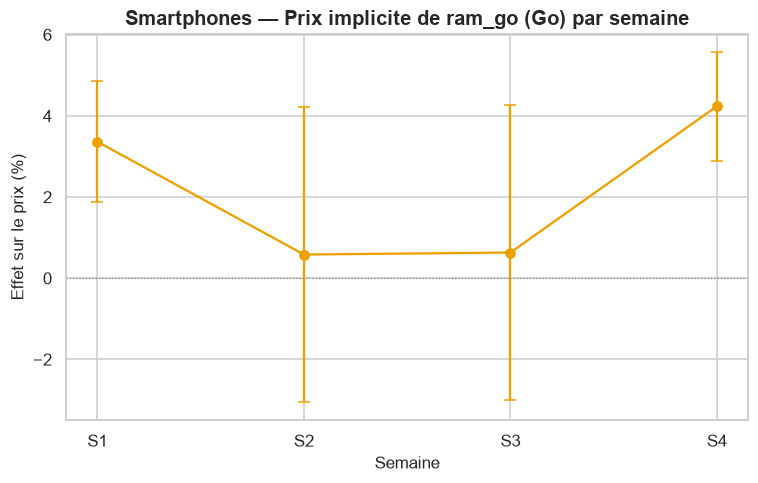

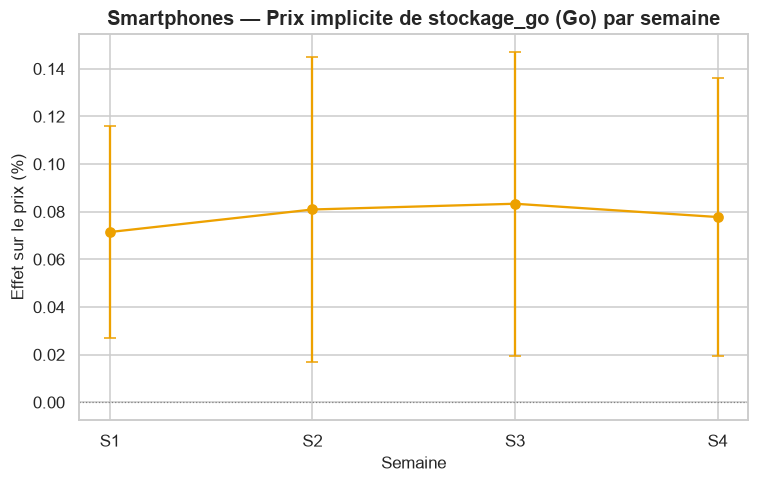

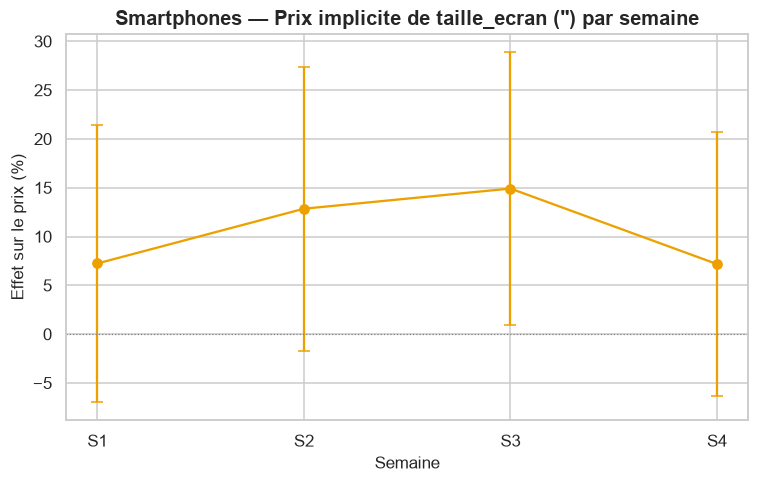

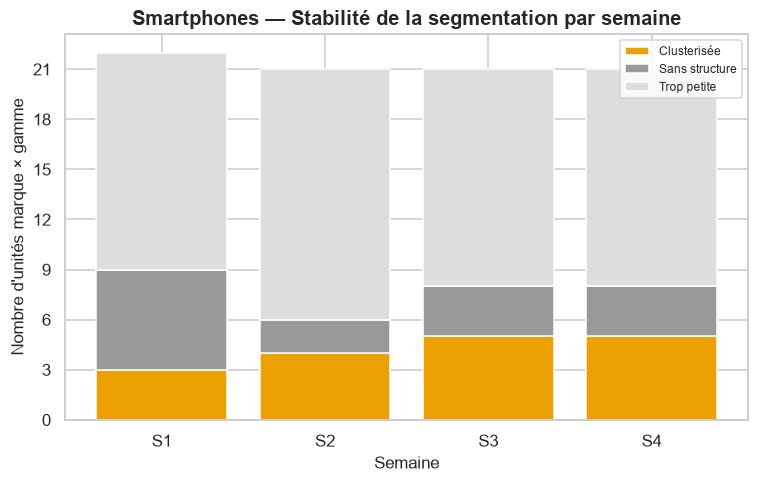

In [39]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    for feat, series in coef_by_week.items():
        if len(series) >= 2:
            plot_coefficient_stability(series, feat, CATEGORY, feature_unit=FEATURE_UNITS.get(feat, ""))
    plot_outcome_stability(outcome_by_week, CATEGORY)


**Interprétation — Pont hédonique.**

Prix implicite de la RAM : +0.17%/Go en S1 (p=0.948, non significatif) → +0.22%/Go en S3 (p=0.907, non significatif) — **stable**. Prix implicite du stockage : +0.03%/Go en S1 (p=0.161, non significatif) → +0.03%/Go en S3 (p=0.173, non significatif) — **stable**. Prix implicite de la taille d'écran : -1.87%/" en S1 (p=0.875, non significatif) → +1.56%/" en S3 (p=0.846, non significatif) — **a évolué**. Stabilité de la segmentation technique — S1 : 3/22 unités marque×gamme clusterisées ; S2 : 4/21 unités marque×gamme clusterisées ; S3 : 5/21 unités marque×gamme clusterisées.


**Synthèse — Smartphones.**

Sur 3 semaine(s) observée(s) (S1, S2, S3), Smartphones montre un marché globalement stable en prix : indice mix-inclus 100.0 contre 100.0 sur le panel apparié.


### 3.4 Téléphones Portables


In [40]:
CATEGORY = "telephones_portables"
df_long, weeks_found = load_all_weeks(CATEGORY, PROCESSED_ROOT, RAW_ROOT)
print(f"{CATEGORY_LABELS[CATEGORY]} : {len(weeks_found)} semaine(s) trouvée(s) -- {weeks_found}")
if not df_long.empty:
    print(df_long.groupby("semaine")["url"].nunique().rename("n_produits").to_frame())


Téléphones Portables : 4 semaine(s) trouvée(s) -- [1, 2, 3, 4]
         n_produits
semaine            
1                69
2                74
3                74
4                74


#### 3.4.1 Continuité et qualité inter-semaines


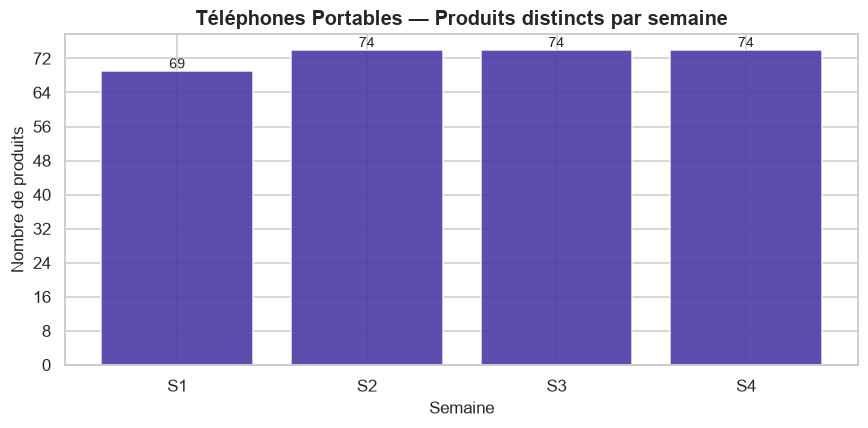

In [41]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    counts, transitions, panel_urls = compute_continuity(df_long)
    plot_continuity(counts, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section continuité ignorée.")


In [42]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    print(f"Panel apparié sur toutes les semaines : {len(panel_urls)} produits.")
    transitions


Panel apparié sur toutes les semaines : 53 produits.


**Interprétation — Continuité.**

3 semaine(s) disponible(s) pour cette catégorie (S1=69, S2=74, S3=74 produits). S1→S2 : 14 produit(s) entrant(s), 9 sortant(s), 60 apparié(s) (33.3% de rotation du catalogue). S2→S3 : 7 produit(s) entrant(s), 7 sortant(s), 67 apparié(s) (18.9% de rotation du catalogue). Panel apparié sur **toutes** les semaines disponibles : 53 produits.


#### 3.4.2 Évolution des prix


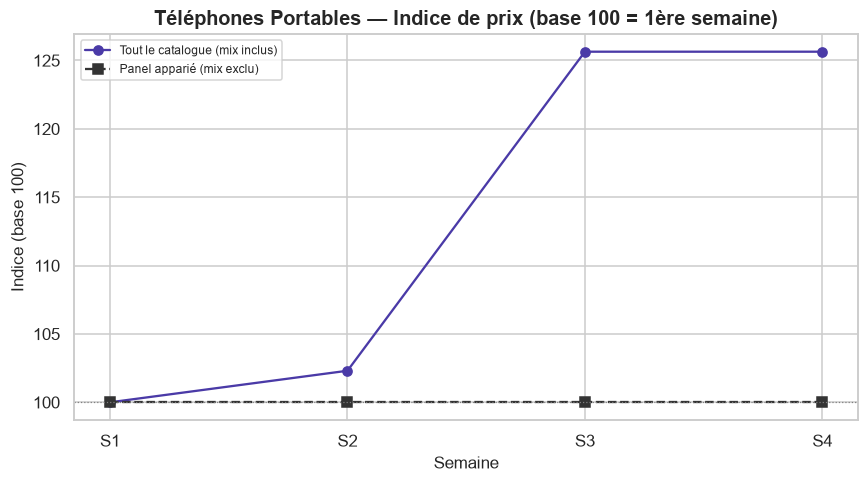

In [43]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    evolution = compute_price_evolution(df_long)
    plot_price_index(evolution, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section prix ignorée.")


In [44]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    evolution["deltas"]


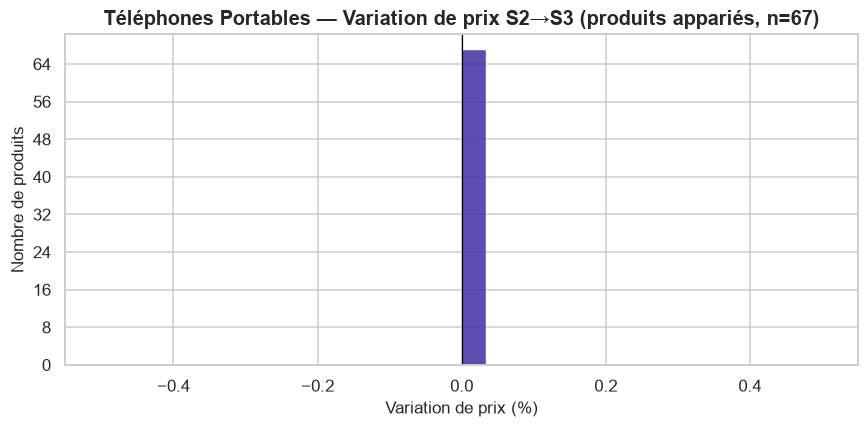

In [45]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    panel_pair = set(df_long.loc[df_long.semaine == 2, "url"]) & set(df_long.loc[df_long.semaine == 3, "url"])
    _ = plot_price_deltas(df_long, CATEGORY, 2, 3, panel_pair)


**Interprétation — Évolution des prix.**

Sur tout le catalogue (mix inclus), l'indice de prix médian passe de 100 (S1) à 125.6 en S3 (hausse, +25.6 points). Mais sur le panel apparié (mêmes produits suivis dans le temps, mix exclu), l'indice reste à 100.0 (+0.0 pts) : l'essentiel du mouvement observé sur tout le catalogue est donc un effet de **changement de mix** (nouveaux produits à un positionnement différent), pas une vraie variation de prix des produits eux-mêmes. Produits appariés S1→S2 (n=60) : 0.0% en hausse, 0.0% en baisse, 100.0% stables (variation médiane : +0.0%). Produits appariés S2→S3 (n=67) : 0.0% en hausse, 0.0% en baisse, 100.0% stables (variation médiane : +0.0%).


#### 3.4.3 Évolution des caractéristiques


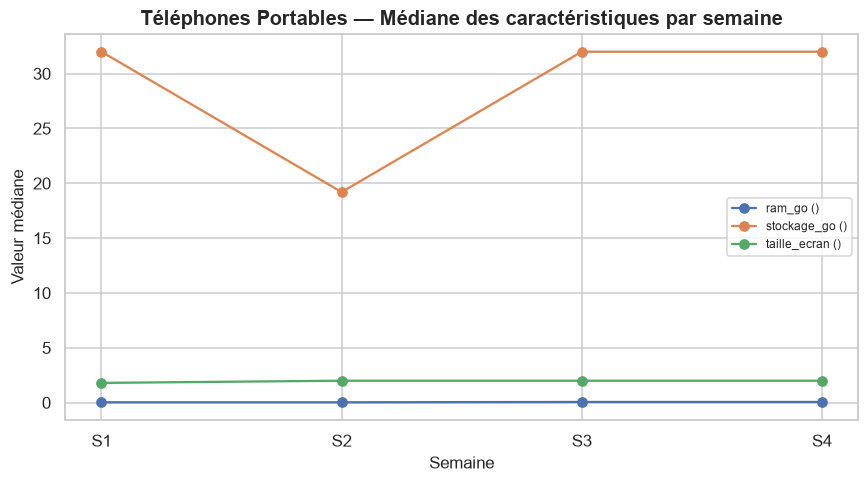

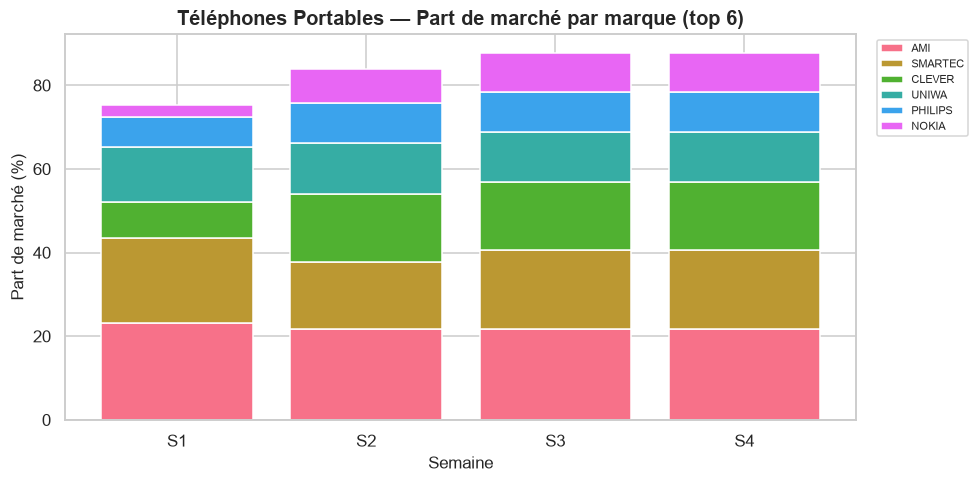

In [46]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    common_continuous_features = ['ram_go', 'stockage_go', 'taille_ecran']
    numeric_evol, brand_share = compute_characteristic_evolution(df_long, common_continuous_features)
    plot_characteristic_evolution(numeric_evol, CATEGORY)
    plot_brand_share(brand_share, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section caractéristiques ignorée.")


In [47]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    numeric_evol


**Interprétation — Caractéristiques.**

ram_go médian : 0.0 → 0.1 (+0.0); taille_ecran médian : 1.8 → 2.0 (+0.2). Plus forte variation de part de marché : **EVERTEK** (11.6% → 2.7%, -8.9 pts).


#### 3.4.4 Pont vers le modèle hédonique


Ré-estime le modèle hédonique de `src/models/hedonic_model.py` (stratégie A — un modèle par semaine, pentes
communes, `cluster_id` en effets fixes) **indépendamment pour chaque semaine disponible**, et suit le **prix
implicite** (effet en %, `exp(β)-1`) des caractéristiques communes à toutes les semaines. Le garde-fou de
circularité du module s'applique tel quel : `prix_tnd`/`gamme_prix` ne peuvent jamais atteindre la matrice de
design.


In [48]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    coef_by_week = {feat: {} for feat in common_continuous_features}
    outcome_by_week = {}
    for w in weeks_found:
        df_week = week_slice(df_long, w)
        cont_w, cat_w = _classify_features(df_week, exclude=TEMPORAL_EXCLUDE)
        df_tiers, brand_plan = compute_price_tiers(df_week)
        if df_tiers.empty:
            print(f"S{w} : aucune marque retenue, semaine ignorée pour le pont hédonique.")
            continue
        df_clustered, unit_summary = compute_cluster_labels(
            df_tiers, CATEGORY, continuous_features=cont_w, categorical_features=cat_w)
        model, X, y = fit_strategy_a(df_clustered, cont_w, cat_w)
        coefs = model.get_coefficients().set_index("feature")
        for feat in common_continuous_features:
            if feat in coefs.index:
                coef_by_week[feat][w] = {
                    "coefficient": coefs.loc[feat, "coefficient"],
                    "std_err": coefs.loc[feat, "std_err"],
                    "p_value": coefs.loc[feat, "p_value"],
                    "pct_effect": coefs.loc[feat, "pct_effect"],
                }
        outcome_by_week[w] = unit_summary["outcome"].value_counts().to_dict()
        print(f"S{w} : n={int(model.nobs)}, adj_R²={model.rsquared_adj:.3f}, "
              f"{len(cont_w)} caractéristique(s) continue(s), {len(cat_w)} catégorielle(s)")
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- pont hédonique ignoré.")


S1 : n=58, adj_R²=0.806, 3 caractéristique(s) continue(s), 2 catégorielle(s)
S2 : n=70, adj_R²=0.929, 3 caractéristique(s) continue(s), 2 catégorielle(s)


S3 : n=65, adj_R²=0.799, 3 caractéristique(s) continue(s), 2 catégorielle(s)


S4 : n=65, adj_R²=0.799, 3 caractéristique(s) continue(s), 2 catégorielle(s)


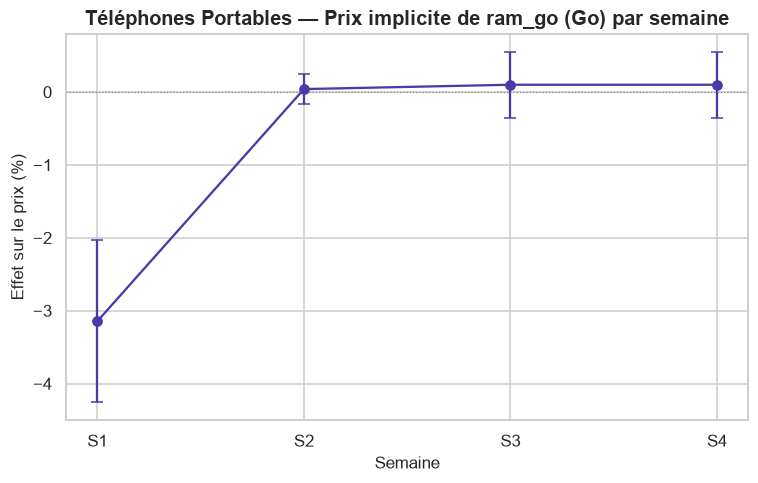

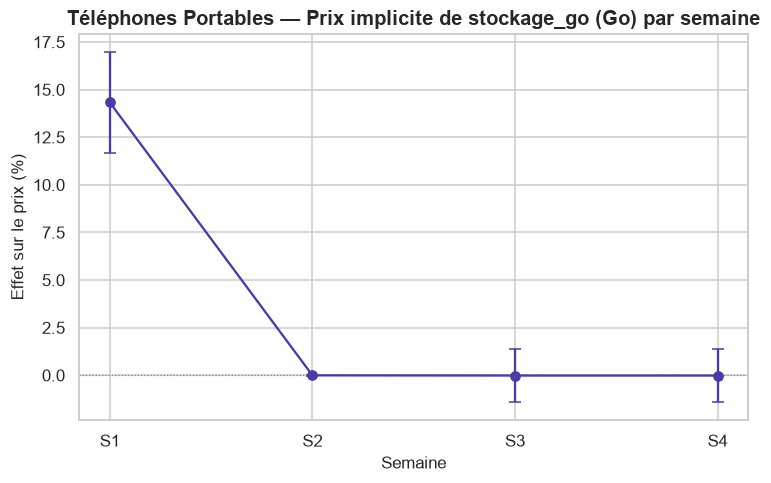

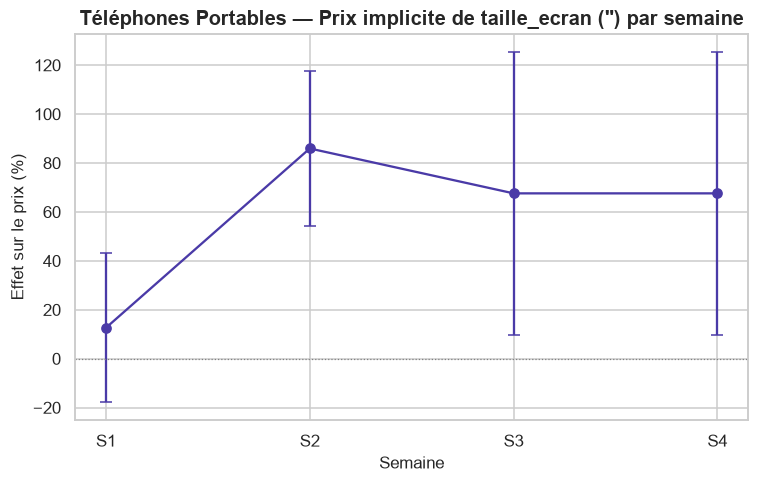

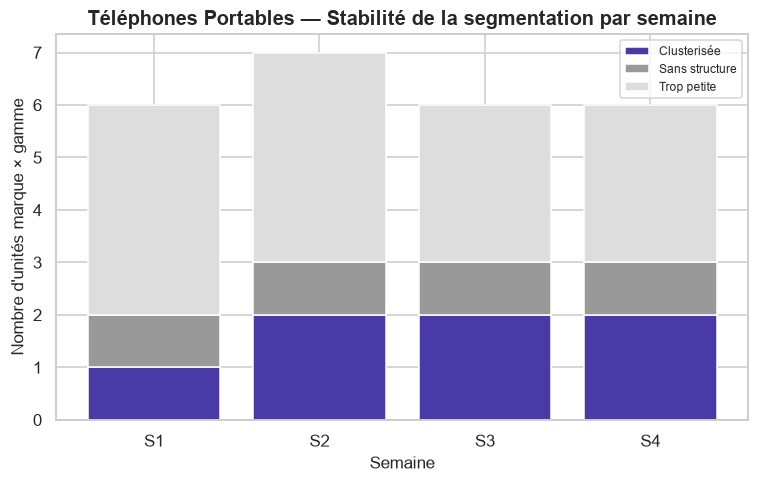

In [49]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    for feat, series in coef_by_week.items():
        if len(series) >= 2:
            plot_coefficient_stability(series, feat, CATEGORY, feature_unit=FEATURE_UNITS.get(feat, ""))
    plot_outcome_stability(outcome_by_week, CATEGORY)


**Interprétation — Pont hédonique.**

Prix implicite de la RAM : -1.45%/Go en S1 (p=0.084, non significatif) → +0.02%/Go en S3 (p=0.932, non significatif) — **a évolué**. Prix implicite du stockage : +14.47%/Go en S1 (p=2.96e-12, significatif) → -0.01%/Go en S3 (p=0.996, non significatif) — **a évolué**. Prix implicite de la taille d'écran : -3.91%/" en S1 (p=0.878, non significatif) → +44.51%/" en S3 (p=0.0916, non significatif) — **a évolué**. Stabilité de la segmentation technique — S1 : 1/6 unités marque×gamme clusterisées ; S2 : 2/7 unités marque×gamme clusterisées ; S3 : 2/6 unités marque×gamme clusterisées.


**Synthèse — Téléphones Portables.**

Sur 3 semaine(s) observée(s) (S1, S2, S3), Téléphones Portables montre un mouvement de prix affiché dominé par un effet de mix, pas une vraie repricing : indice mix-inclus 125.6 contre 100.0 sur le panel apparié.


### 3.5 Téléviseurs


In [50]:
CATEGORY = "televiseurs"
df_long, weeks_found = load_all_weeks(CATEGORY, PROCESSED_ROOT, RAW_ROOT)
print(f"{CATEGORY_LABELS[CATEGORY]} : {len(weeks_found)} semaine(s) trouvée(s) -- {weeks_found}")
if not df_long.empty:
    print(df_long.groupby("semaine")["url"].nunique().rename("n_produits").to_frame())


Téléviseurs : 4 semaine(s) trouvée(s) -- [1, 2, 3, 4]
         n_produits
semaine            
1               112
2               111
3               111
4               114


#### 3.5.1 Continuité et qualité inter-semaines


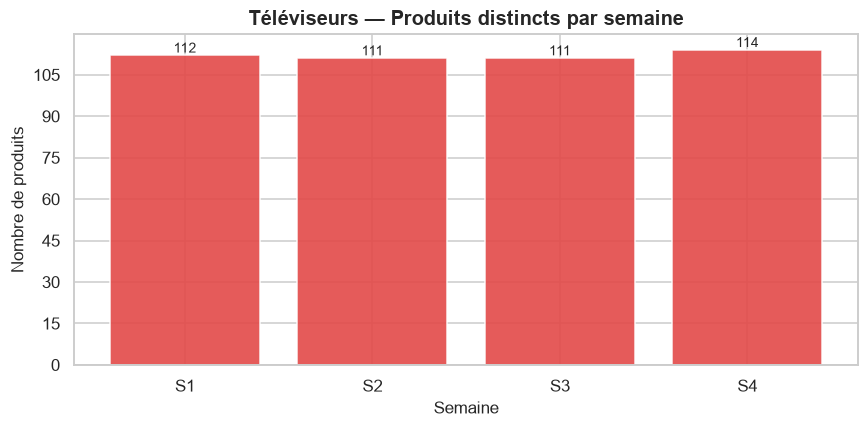

In [51]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    counts, transitions, panel_urls = compute_continuity(df_long)
    plot_continuity(counts, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section continuité ignorée.")


In [52]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    print(f"Panel apparié sur toutes les semaines : {len(panel_urls)} produits.")
    transitions


Panel apparié sur toutes les semaines : 106 produits.


**Interprétation — Continuité.**

3 semaine(s) disponible(s) pour cette catégorie (S1=112, S2=111, S3=111 produits). S1→S2 : 1 produit(s) entrant(s), 2 sortant(s), 110 apparié(s) (2.7% de rotation du catalogue). S2→S3 : 0 produit(s) entrant(s), 0 sortant(s), 111 apparié(s) (0.0% de rotation du catalogue). Panel apparié sur **toutes** les semaines disponibles : 110 produits.


#### 3.5.2 Évolution des prix


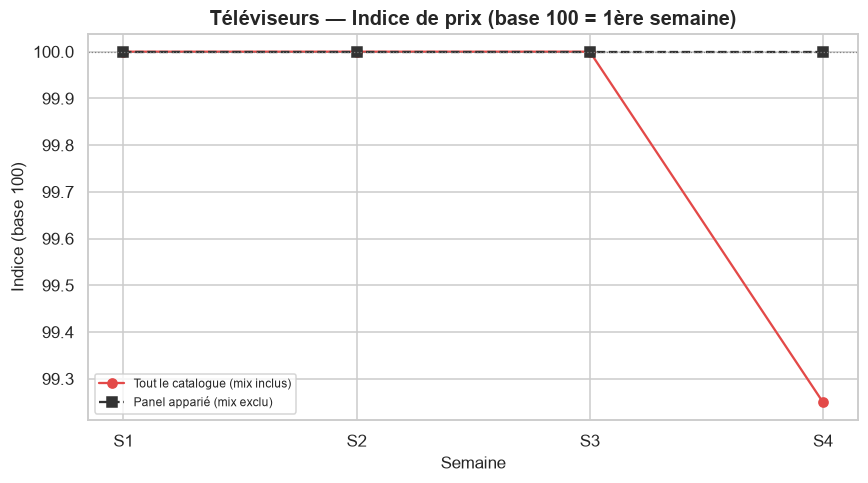

In [53]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    evolution = compute_price_evolution(df_long)
    plot_price_index(evolution, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section prix ignorée.")


In [54]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    evolution["deltas"]


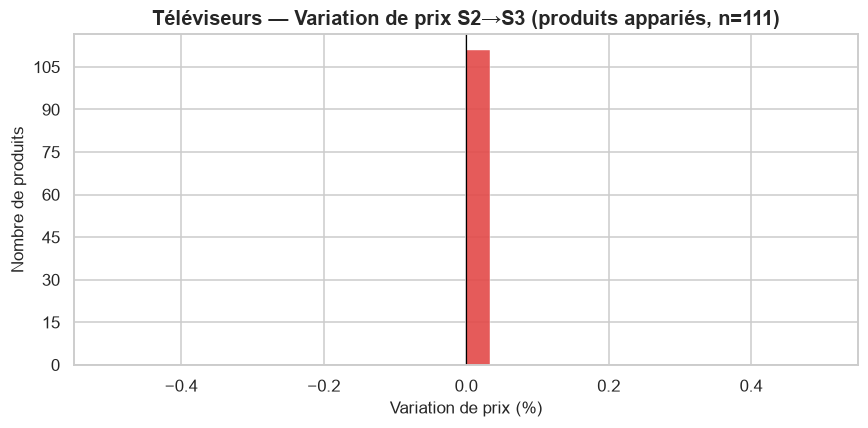

In [55]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    panel_pair = set(df_long.loc[df_long.semaine == 2, "url"]) & set(df_long.loc[df_long.semaine == 3, "url"])
    _ = plot_price_deltas(df_long, CATEGORY, 2, 3, panel_pair)


**Interprétation — Évolution des prix.**

Sur tout le catalogue (mix inclus), l'indice de prix médian passe de 100 (S1) à 100.0 en S3 (quasi-stable, +0.0 points). Le panel apparié confirme un mouvement similaire (+0.0 pts) : il s'agit bien d'un changement de **prix**, pas seulement de mix. Produits appariés S1→S2 (n=110) : 0.9% en hausse, 0.9% en baisse, 98.2% stables (variation médiane : +0.0%). Produits appariés S2→S3 (n=111) : 0.0% en hausse, 0.0% en baisse, 100.0% stables (variation médiane : +0.0%).


#### 3.5.3 Évolution des caractéristiques


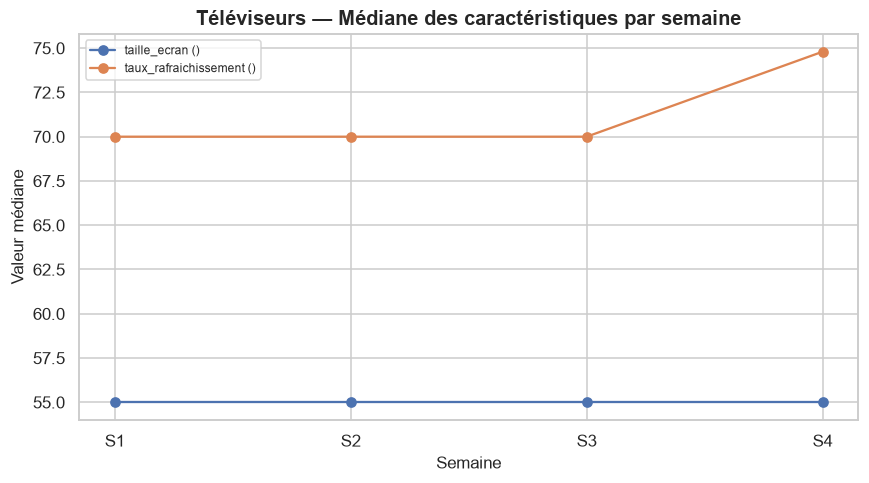

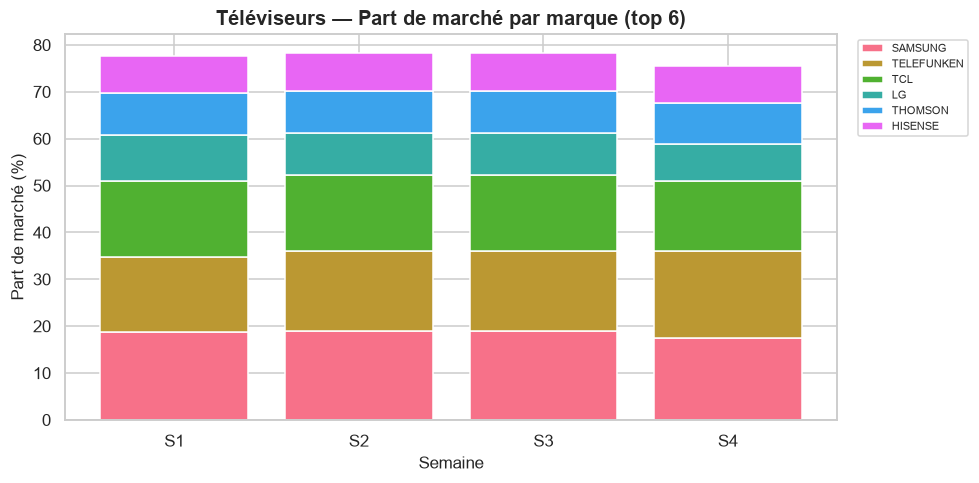

In [56]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    common_continuous_features = ['taille_ecran', 'taux_rafraichissement']
    numeric_evol, brand_share = compute_characteristic_evolution(df_long, common_continuous_features)
    plot_characteristic_evolution(numeric_evol, CATEGORY)
    plot_brand_share(brand_share, CATEGORY)
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- section caractéristiques ignorée.")


In [57]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    numeric_evol


**Interprétation — Caractéristiques.**

Caractéristiques techniques médianes strictement stables sur la période observée. Plus forte variation de part de marché : **TELEFUNKEN** (16.1% → 17.1%, +1.0 pts).


#### 3.5.4 Pont vers le modèle hédonique


Ré-estime le modèle hédonique de `src/models/hedonic_model.py` (stratégie A — un modèle par semaine, pentes
communes, `cluster_id` en effets fixes) **indépendamment pour chaque semaine disponible**, et suit le **prix
implicite** (effet en %, `exp(β)-1`) des caractéristiques communes à toutes les semaines. Le garde-fou de
circularité du module s'applique tel quel : `prix_tnd`/`gamme_prix` ne peuvent jamais atteindre la matrice de
design.


In [58]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    coef_by_week = {feat: {} for feat in common_continuous_features}
    outcome_by_week = {}
    for w in weeks_found:
        df_week = week_slice(df_long, w)
        cont_w, cat_w = _classify_features(df_week, exclude=TEMPORAL_EXCLUDE)
        df_tiers, brand_plan = compute_price_tiers(df_week)
        if df_tiers.empty:
            print(f"S{w} : aucune marque retenue, semaine ignorée pour le pont hédonique.")
            continue
        df_clustered, unit_summary = compute_cluster_labels(
            df_tiers, CATEGORY, continuous_features=cont_w, categorical_features=cat_w)
        model, X, y = fit_strategy_a(df_clustered, cont_w, cat_w)
        coefs = model.get_coefficients().set_index("feature")
        for feat in common_continuous_features:
            if feat in coefs.index:
                coef_by_week[feat][w] = {
                    "coefficient": coefs.loc[feat, "coefficient"],
                    "std_err": coefs.loc[feat, "std_err"],
                    "p_value": coefs.loc[feat, "p_value"],
                    "pct_effect": coefs.loc[feat, "pct_effect"],
                }
        outcome_by_week[w] = unit_summary["outcome"].value_counts().to_dict()
        print(f"S{w} : n={int(model.nobs)}, adj_R²={model.rsquared_adj:.3f}, "
              f"{len(cont_w)} caractéristique(s) continue(s), {len(cat_w)} catégorielle(s)")
else:
    print(f"Nécessite >= {MIN_WEEKS_REQUIRED} semaines -- pont hédonique ignoré.")


S1 : n=105, adj_R²=0.973, 2 caractéristique(s) continue(s), 10 catégorielle(s)
S2 : n=104, adj_R²=0.974, 2 caractéristique(s) continue(s), 10 catégorielle(s)
S3 : n=104, adj_R²=0.974, 2 caractéristique(s) continue(s), 10 catégorielle(s)
S4 : n=103, adj_R²=0.976, 2 caractéristique(s) continue(s), 11 catégorielle(s)


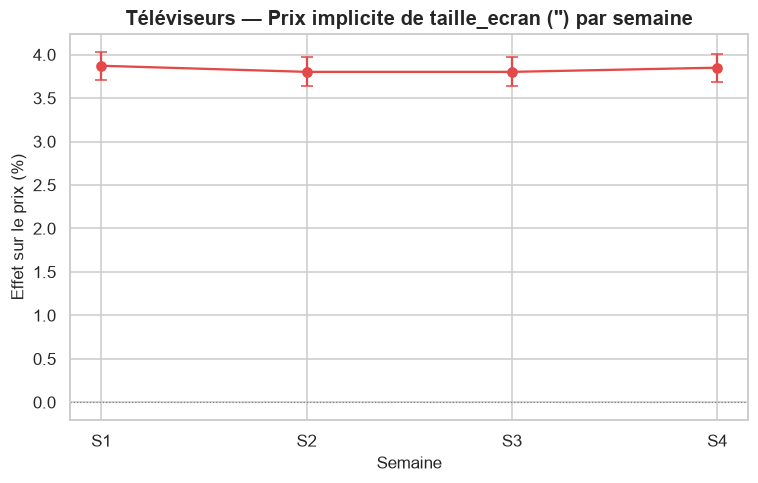

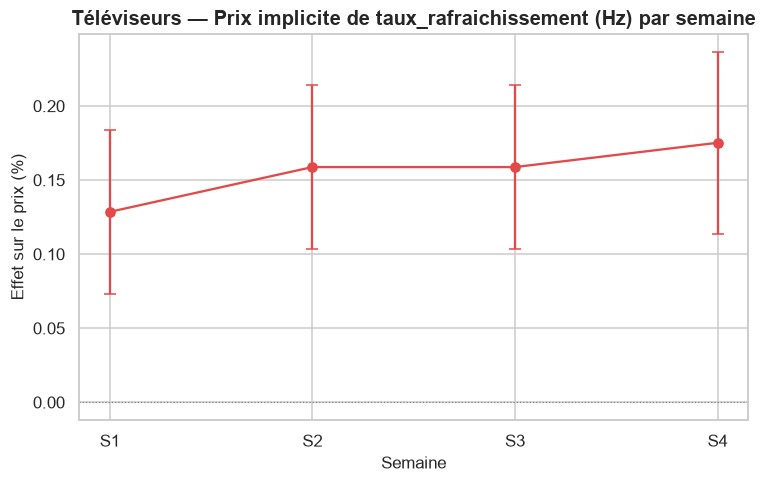

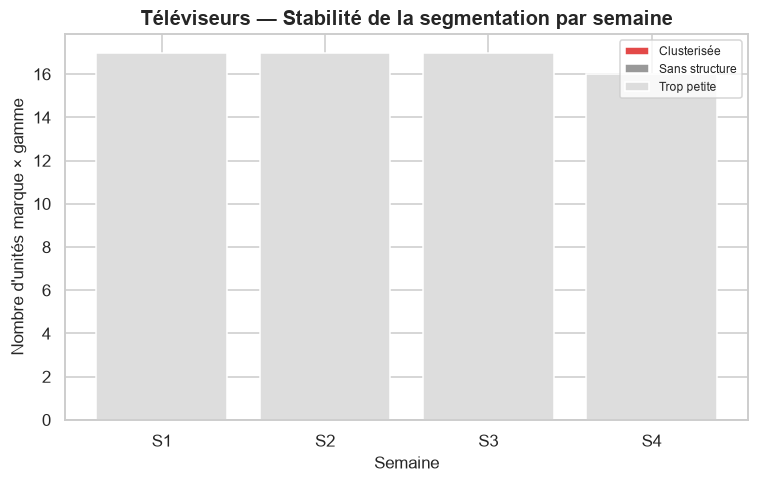

In [59]:
if len(weeks_found) >= MIN_WEEKS_REQUIRED:
    for feat, series in coef_by_week.items():
        if len(series) >= 2:
            plot_coefficient_stability(series, feat, CATEGORY, feature_unit=FEATURE_UNITS.get(feat, ""))
    plot_outcome_stability(outcome_by_week, CATEGORY)


**Interprétation — Pont hédonique.**

Prix implicite de la taille d'écran : +3.45%/" en S1 (p=1.55e-41, significatif) → +3.31%/" en S3 (p=3.06e-38, significatif) — **stable**. Prix implicite du taux de rafraîchissement : +0.14%/Hz en S1 (p=0.0331, significatif) → +0.14%/Hz en S3 (p=0.0234, significatif) — **stable**. Stabilité de la segmentation technique — S1 : 0/17 unités marque×gamme clusterisées ; S2 : 0/17 unités marque×gamme clusterisées ; S3 : 0/17 unités marque×gamme clusterisées.


**Synthèse — Téléviseurs.**

Sur 3 semaine(s) observée(s) (S1, S2, S3), Téléviseurs montre un marché globalement stable en prix : indice mix-inclus 100.0 contre 100.0 sur le panel apparié.


## 4. Synthèse générale et conclusion


### 4.1 Vue d'ensemble par catégorie

- **pc_bureau** (3 semaines) : indice mix-inclus +0.2 pts en S3.
- **pc_portables** (3 semaines) : indice mix-inclus +2.0 pts en S3.
- **smartphones** (3 semaines) : indice mix-inclus +0.0 pts en S3.
- **telephones_portables** (3 semaines) : indice mix-inclus +25.6 pts en S3.
- **televiseurs** (3 semaines) : indice mix-inclus +0.0 pts en S3.


### 4.2 Limites

- **Semaine 3 partielle sur plusieurs catégories.** Au moment de l'exécution de ce notebook, seule la catégorie
  PC Portables dispose d'une 3ᵉ semaine de collecte (les 4 autres catégories n'ont que 2 semaines) — et cette
  3ᵉ semaine était elle-même une collecte encore **en cours** au moment du snapshot. Ce n'est pas traité comme
  une anomalie : c'est exactement le type d'écart que la section « continuité » (§3.x.1) est censée détecter et
  signaler, plutôt que masquer.
- **Panel apparié = survivants.** Le panel apparié sur toutes les semaines disponibles est par construction
  composé des produits qui n'ont *pas* été retirés du catalogue — un biais de survie. Si les produits retirés
  étaient systématiquement ceux dont le prix avait le plus bougé, l'indice apparié sous-estimerait la vraie
  variation de prix du marché.
- **Fenêtre temporelle courte.** 2 à 3 semaines ne permettent de détecter que des mouvements déjà substantiels ;
  ni saisonnalité ni tendance de fond ne peuvent être établies à ce stade — ce notebook est conçu pour être
  ré-exécuté à mesure que de nouvelles semaines s'accumulent (§1.1).
- **Schéma de caractéristiques non garanti stable.** La sélection de features (`select_features_for_category`)
  est recalculée indépendamment chaque semaine ; une caractéristique peut apparaître ou disparaître d'une
  semaine à l'autre (cf. §1.5) — le suivi de stabilité se limite donc au socle commun, par construction plus
  restreint que l'ensemble des caractéristiques réellement utilisées chaque semaine individuellement.

### 4.3 Conclusion générale et prochaines étapes

Ce notebook répond à la question posée en introduction — prix ou mix ? — catégorie par catégorie, en s'appuyant
systématiquement sur le panel apparié comme contre-épreuve de l'indice brut. Il réutilise directement le module
hédonique déjà construit pour ce projet (`src/models/hedonic_model.py`) plutôt que de dupliquer sa logique,
ce qui garantit que le pont vers le hédonique (§3.x.4) reste cohérent avec le reste du projet.

**Prochaines étapes envisageables** (hors du périmètre de ce notebook) :
- Une fois davantage de semaines accumulées, remplacer les comparaisons S1→S2(→S3) par une vraie régression sur
  le temps (tendance + saisonnalité) plutôt que des deltas point à point.
- Suivre explicitement les produits **sortis** du catalogue (prix à la sortie vs. prix moyen du marché à ce
  moment) pour quantifier le biais de survie identifié en §4.2.
- Croiser la stabilité des `cluster_id` eux-mêmes (pas seulement leur nombre par état) d'une semaine à l'autre :
  un même produit change-t-il de cluster technique au fil du temps, ou la segmentation est-elle stable au
  niveau produit et pas seulement au niveau agrégé ?
